# 라이브러리 및 준비

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import json
import optuna
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, roc_curve
)
from scipy.stats import norm
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)


In [2]:
# ✅ 한글 폰트 설정 (Mac용)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 상수정의
RANDOM_STATE = 42
TEST_SIZE = 0.20
VALID_SIZE_WITHIN_TRAIN = 0.20
N_TRIALS = 50

CHURN_THRESHOLDS = [30, 60, 90]
CHURN_TARGETS = [f'Churn_{d}' for d in CHURN_THRESHOLDS]
IMPULSE_TARGETS = ['ImpulseFlag']
TARGETS = CHURN_TARGETS + IMPULSE_TARGETS

# ── Leakage 방지 ──
LABEL_SOURCE_COLS = {
    # Churn_* 라벨은 Recency > threshold로 생성되므로 Recency는 학습에서 제거한다.
    'Churn': ['Recency'],
    'Churn_30': ['Recency'],
    'Churn_60': ['Recency'],
    'Churn_90': ['Recency'],
    # ImpulseFlag는 주문 매출이 고객 AOV의 1.5배를 넘고 신규 품목이 포함되는지로 생성된다.
    # 관련 파생변수는 보수적으로 제외한다.
    'ImpulseFlag': ['ImpulsePurchaseIndex', 'AOV', 'New_Category_Ratio', 'Max_Single_Order_Revenue'],
}
ALWAYS_DROP = [
    'CustomerID', 'Churn', *CHURN_TARGETS,
    'ImpulsePurchaseIndex', 'ImpulseFlag',
]

# ── 넛지 유형별 Feature 그룹 ──
FEATURE_GROUPS = {
    'RFM_baseline': [
        'Recency', 'Frequency', 'Monetary', 'AOV',
        'Avg_Items_per_Order', 'Active_Months', 'Purchase_Span',
        'Revenue_Consistency',
    ],
    '인지적효율성': [
        'Basket_Diversity_Index', 'Avg_Unique_Items_per_Basket',
        'Large_Basket_Ratio', 'Max_Single_Order_Revenue',
    ],
    '유도성': [
        'Repurchase_Rate', 'Top_Product_Concentration',
        'Avg_Repurchase_Interval',
    ],
    '흥미성': ['New_Category_Ratio'],
    '긍정성': [
        'Avg_Unit_Price', 'Price_Variance', 'Low_Price_Item_Ratio',
        'Return_Rate', 'Days_to_Return_Purchase',
        'Cancellation_Rate', 'Return_Recovery_Ratio',
    ],
    '비교성': ['Country_Trend_Alignment', 'Country_Purchase_Rank', 'UK_Flag'],
    '일관성': ['Category_Concentration_Std'],
    '타성': [
        'Hour_Entropy', 'DayOfWeek_Entropy', 'Preferred_Hour',
        'Weekend_Ratio', 'IPI_Mean', 'IPI_Std', 'CV_Interval',
        'Purchase_Rhythm_Score',
    ],
}


def get_feature_sets():
    """RFM 8개 / RFM+HCI 35개 Feature Set 반환."""
    rfm = FEATURE_GROUPS['RFM_baseline']
    hci = []
    for k, v in FEATURE_GROUPS.items():
        if k != 'RFM_baseline':
            hci.extend(v)
    rfm_hci = rfm + hci
    return {'rfm': rfm, 'rfm_hci': rfm_hci}


def get_label_source_cols(target_col):
    """종속변수 라벨링에 사용된 독립변수 후보를 반환한다."""
    if target_col.startswith('Churn_'):
        return LABEL_SOURCE_COLS['Churn']
    return LABEL_SOURCE_COLS.get(target_col, [])


def clean_features(feature_cols, target_col, df_columns):
    """Leakage, 식별자, 다른 target 컬럼을 제거한 유효 feature 리스트를 반환한다."""
    leak = set(get_label_source_cols(target_col))
    blocked = set(ALWAYS_DROP) | leak
    cleaned = [c for c in feature_cols if c in df_columns and c not in blocked]
    removed = [c for c in feature_cols if c in df_columns and c in blocked]
    return cleaned, removed


# 데이터 로드

In [8]:
DATASET_FILES = {
    'A_FreqGE2': 'modeling_ready_A_freqGE2.csv',
    'B_All': 'modeling_ready_B_all.csv',
}


def load_modeling_dataset(path):
    try:
        return pd.read_csv(path)
    except FileNotFoundError as exc:
        raise FileNotFoundError(
            f"{path} 파일이 없습니다. Processing_final.ipynb를 먼저 실행해 CSV를 생성하세요."
        ) from exc


df_A = load_modeling_dataset(DATASET_FILES['A_FreqGE2'])
df_B = load_modeling_dataset(DATASET_FILES['B_All'])
feature_sets = get_feature_sets()

print(f"실험A (Freq≥2): {df_A.shape}")
print(f"실험B (전체):   {df_B.shape}")
print(f"Feature sets: RFM={len(feature_sets['rfm'])}개, RFM+HCI={len(feature_sets['rfm_hci'])}개")

for ds_name, df in {'A_FreqGE2': df_A, 'B_All': df_B}.items():
    print(f"\n[{ds_name}] 종속변수 분포")
    for target in TARGETS:
        if target in df.columns:
            print(f"  {target}: {df[target].sum():,}명 ({df[target].mean():.1%})")


실험A (Freq≥2): (2845, 42)
실험B (전체):   (6516, 43)
Feature sets: RFM=8개, RFM+HCI=35개

[A_FreqGE2] 종속변수 분포
  Churn_30: 1,398명 (49.1%)
  Churn_60: 881명 (31.0%)
  Churn_90: 602명 (21.2%)
  ImpulseFlag: 1,370명 (48.2%)

[B_All] 종속변수 분포
  Churn_30: 4,617명 (70.9%)
  Churn_60: 3,671명 (56.3%)
  Churn_90: 3,044명 (46.7%)
  ImpulseFlag: 1,370명 (21.0%)


# 모델 및 평가 함수 정의 

In [11]:
# 모델 정의 및 Optuna 탐색공간

def _xgb_scale_pos_weight(y):
    positives = max(int((y == 1).sum()), 1)
    negatives = int((y == 0).sum())
    return negatives / positives


def suggest_params(model_name, trial):
    """모델별 Optuna hyperparameter search space."""
    if model_name == 'Logistic':
        return {
            'C': trial.suggest_float('C', 1e-3, 1e2, log=True),
        }

    if model_name == 'RandomForest':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 200, 700, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        }

    if model_name == 'XGBoost':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
            'max_depth': trial.suggest_int('max_depth', 2, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.20, log=True),
            'subsample': trial.suggest_float('subsample', 0.60, 1.00),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.60, 1.00),
            'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 10.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        }

    if model_name == 'CatBoost':
        return {
            'iterations': trial.suggest_int('iterations', 200, 800, step=100),
            'depth': trial.suggest_int('depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.20, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            'random_strength': trial.suggest_float('random_strength', 0.0, 2.0),
        }

    raise ValueError(f"Unknown model: {model_name}")


def build_model(model_name, params=None, y_train=None):
    """모델명과 파라미터로 estimator를 생성한다."""
    params = params or {}

    if model_name == 'Logistic':
        return LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE,
            class_weight='balanced',
            solver='liblinear',
            **params,
        )

    if model_name == 'RandomForest':
        return RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight='balanced',
            n_jobs=-1,
            **params,
        )

    if model_name == 'XGBoost':
        return XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            tree_method='hist',
            n_jobs=-1,
            scale_pos_weight=_xgb_scale_pos_weight(y_train) if y_train is not None else 1,
            **params,
        )

    if model_name == 'CatBoost':
        return CatBoostClassifier(
            random_state=RANDOM_STATE,
            verbose=0,
            loss_function='Logloss',
            eval_metric='AUC',
            auto_class_weights='Balanced',
            allow_writing_files=False,
            **params,
        )

    raise ValueError(f"Unknown model: {model_name}")


def get_model_names():
    return ['Logistic', 'RandomForest', 'XGBoost', 'CatBoost']


In [13]:
# 평가 함수

def _safe_auc(y_true, y_proba):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_proba)


def evaluate_model(y_true, y_pred, y_proba):
    """분류 성능 5개 핵심 지표를 딕셔너리로 반환한다."""
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'AUC': _safe_auc(y_true, y_proba),
    }


def predict_metrics(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return evaluate_model(y, y_pred, y_proba), y_pred, y_proba


def delong_test(y_true, proba_A, proba_B):
    """DeLong test: 두 ROC-AUC 간 통계적 유의성 검정."""
    n1 = (y_true == 1).sum()
    n0 = (y_true == 0).sum()
    if n1 < 2 or n0 < 2:
        return np.nan, np.nan

    def compute_placement(proba, y):
        pos_scores = proba[y == 1]
        neg_scores = proba[y == 0]
        V10 = np.array([np.mean(neg_scores < p) + 0.5 * np.mean(neg_scores == p)
                         for p in pos_scores])
        V01 = np.array([np.mean(pos_scores > n) + 0.5 * np.mean(pos_scores == n)
                         for n in neg_scores])
        return V10, V01

    V10_A, V01_A = compute_placement(proba_A, y_true)
    V10_B, V01_B = compute_placement(proba_B, y_true)

    S10 = np.cov(V10_A, V10_B)
    S01 = np.cov(V01_A, V01_B)
    S = S10 / n1 + S01 / n0

    auc_A = roc_auc_score(y_true, proba_A)
    auc_B = roc_auc_score(y_true, proba_B)
    var_diff = S[0, 0] + S[1, 1] - 2 * S[0, 1]

    if var_diff <= 0:
        return 0.0, 1.0

    z = (auc_A - auc_B) / np.sqrt(var_diff)
    p_value = 2 * (1 - norm.cdf(abs(z)))
    return z, p_value


In [15]:
# 단일 실험 실행 함수

def tune_hyperparameters(
    model_name,
    X_train_inner,
    y_train_inner,
    X_val,
    y_val,
    n_trials=N_TRIALS,
    random_state=RANDOM_STATE,
):
    """Validation AUC를 기준으로 Optuna hyperparameter tuning을 수행한다."""
    if len(np.unique(y_val)) < 2:
        raise ValueError("Validation set has fewer than 2 classes; AUC cannot be optimized.")

    def objective(trial):
        params = suggest_params(model_name, trial)
        model = build_model(model_name, params=params, y_train=y_train_inner)
        model.fit(X_train_inner, y_train_inner)
        y_val_proba = model.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, y_val_proba)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=random_state),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params, study.best_value, study


def run_single_experiment(
    df,
    feature_cols,
    target_col,
    model_name,
    test_size=TEST_SIZE,
    validation_size=VALID_SIZE_WITHIN_TRAIN,
    random_state=RANDOM_STATE,
    n_trials=N_TRIALS,
):
    """단일 (데이터셋 × Feature Set × 모델 × Target) 실험을 수행한다."""
    valid_cols, removed_cols = clean_features(feature_cols, target_col, df.columns)
    X = df[valid_cols].copy()
    y = df[target_col].astype(int).copy()

    if y.nunique() < 2:
        raise ValueError(f"{target_col} has fewer than 2 classes.")

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    X_train_inner, X_val, y_train_inner, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=validation_size,
        random_state=random_state,
        stratify=y_train_full,
    )

    # Tuning stage: train 64% / validation 16%
    tuning_scaler = StandardScaler()
    X_train_inner_sc = tuning_scaler.fit_transform(X_train_inner)
    X_val_sc = tuning_scaler.transform(X_val)

    best_params, best_validation_auc, study = tune_hyperparameters(
        model_name,
        X_train_inner_sc,
        y_train_inner.values,
        X_val_sc,
        y_val.values,
        n_trials=n_trials,
        random_state=random_state,
    )

    validation_model = build_model(model_name, params=best_params, y_train=y_train_inner.values)
    validation_model.fit(X_train_inner_sc, y_train_inner.values)
    train_metrics, _, _ = predict_metrics(validation_model, X_train_inner_sc, y_train_inner.values)
    validation_metrics, y_val_pred, y_val_proba = predict_metrics(validation_model, X_val_sc, y_val.values)

    # Final stage: validation에서 선택된 hyperparameter를 고정하고 training 80% 전체로 재학습
    final_scaler = StandardScaler()
    X_train_full_sc = final_scaler.fit_transform(X_train_full)
    X_test_sc = final_scaler.transform(X_test)

    final_model = build_model(model_name, params=best_params, y_train=y_train_full.values)
    final_model.fit(X_train_full_sc, y_train_full.values)
    train_full_metrics, _, _ = predict_metrics(final_model, X_train_full_sc, y_train_full.values)
    test_metrics, y_test_pred, y_test_proba = predict_metrics(final_model, X_test_sc, y_test.values)

    split_metrics = pd.DataFrame([
        {'Split': 'Training', **train_full_metrics},
        {'Split': 'Validation', **validation_metrics},
        {'Split': 'Test', **test_metrics},
    ])

    return {
        'test_metrics': test_metrics,
        'train_metrics': train_full_metrics,
        'validation_metrics': validation_metrics,
        'split_metrics': split_metrics,
        'best_params': best_params,
        'best_validation_auc': best_validation_auc,
        'study': study,
        'model': final_model,
        'validation_model': validation_model,
        'scaler': final_scaler,
        'tuning_scaler': tuning_scaler,
        'feature_cols': valid_cols,
        'removed_cols': removed_cols,
        'y_train': y_train_full.values,
        'y_val': y_val.values,
        'y_test': y_test.values,
        'y_val_pred': y_val_pred,
        'y_val_proba': y_val_proba,
        'y_pred': y_test_pred,
        'y_proba': y_test_proba,
        'X_train_sc': X_train_full_sc,
        'X_val_sc': X_val_sc,
        'X_test_sc': X_test_sc,
        'n_train': len(y_train_full),
        'n_validation': len(y_val),
        'n_test': len(y_test),
        'positive_train': int(y_train_full.sum()),
        'positive_validation': int(y_val.sum()),
        'positive_test': int(y_test.sum()),
    }


In [17]:
# 전체 실험 매트릭스 실행

def run_all_experiments(datasets, targets, feature_sets, verbose=True, n_trials=N_TRIALS):
    """전체 실험 조합을 실행한다."""
    rows = []
    split_rows = []
    details = {}

    for ds_name, df in datasets.items():
        for target in targets:
            if target not in df.columns:
                print(f"⚠️ {ds_name}: {target} 컬럼이 없어 건너뜁니다.")
                continue

            for fs_name, fs_cols in feature_sets.items():
                for model_name in get_model_names():
                    exp_key = f"{ds_name}_{fs_name}_{model_name}_{target}"
                    if verbose:
                        print(f"  실행 중: {exp_key}")

                    result = run_single_experiment(
                        df, fs_cols, target, model_name, n_trials=n_trials
                    )

                    row = {
                        'Experiment': exp_key,
                        'Dataset': ds_name,
                        'FeatureSet': fs_name,
                        'FeatureCount': len(result['feature_cols']),
                        'Model': model_name,
                        'Target': target,
                        'N_Train': result['n_train'],
                        'N_Validation': result['n_validation'],
                        'N_Test': result['n_test'],
                        'Positive_Train': result['positive_train'],
                        'Positive_Validation': result['positive_validation'],
                        'Positive_Test': result['positive_test'],
                        'BestValidationAUC': result['best_validation_auc'],
                        'RemovedLeakageCols': ', '.join(result['removed_cols']),
                        'BestParams': json.dumps(result['best_params'], ensure_ascii=False),
                    }
                    for metric, value in result['test_metrics'].items():
                        row[f'Test_{metric}'] = value
                    rows.append(row)

                    split_df = result['split_metrics'].copy()
                    split_df.insert(0, 'Experiment', exp_key)
                    split_df.insert(1, 'Dataset', ds_name)
                    split_df.insert(2, 'Target', target)
                    split_df.insert(3, 'FeatureSet', fs_name)
                    split_df.insert(4, 'Model', model_name)
                    split_rows.append(split_df)
                    details[exp_key] = result

    return pd.DataFrame(rows), pd.concat(split_rows, ignore_index=True), details


# 모델링

In [20]:
print("\n" + "=" * 60)
print("전체 실험 시작 (64 조합)")
print("  - A/B 데이터셋 2개 × Target 4개(Churn_30/60/90 + ImpulseFlag) × Feature set 2개 × 모델 4개")
print("  - Optuna trials: 50회 / 실험")
print("=" * 60)

datasets = {
    'A_FreqGE2': df_A,
    'B_All': df_B,
}
targets = TARGETS

results_df, split_metrics_df, results_detail = run_all_experiments(
    datasets, targets, feature_sets, n_trials=N_TRIALS
)



전체 실험 시작 (64 조합)
  - A/B 데이터셋 2개 × Target 4개(Churn_30/60/90 + ImpulseFlag) × Feature set 2개 × 모델 4개
  - Optuna trials: 50회 / 실험
  실행 중: A_FreqGE2_rfm_Logistic_Churn_30
  실행 중: A_FreqGE2_rfm_RandomForest_Churn_30
  실행 중: A_FreqGE2_rfm_XGBoost_Churn_30
  실행 중: A_FreqGE2_rfm_CatBoost_Churn_30
  실행 중: A_FreqGE2_rfm_hci_Logistic_Churn_30
  실행 중: A_FreqGE2_rfm_hci_RandomForest_Churn_30
  실행 중: A_FreqGE2_rfm_hci_XGBoost_Churn_30
  실행 중: A_FreqGE2_rfm_hci_CatBoost_Churn_30
  실행 중: A_FreqGE2_rfm_Logistic_Churn_60
  실행 중: A_FreqGE2_rfm_RandomForest_Churn_60
  실행 중: A_FreqGE2_rfm_XGBoost_Churn_60
  실행 중: A_FreqGE2_rfm_CatBoost_Churn_60
  실행 중: A_FreqGE2_rfm_hci_Logistic_Churn_60
  실행 중: A_FreqGE2_rfm_hci_RandomForest_Churn_60
  실행 중: A_FreqGE2_rfm_hci_XGBoost_Churn_60
  실행 중: A_FreqGE2_rfm_hci_CatBoost_Churn_60
  실행 중: A_FreqGE2_rfm_Logistic_Churn_90
  실행 중: A_FreqGE2_rfm_RandomForest_Churn_90
  실행 중: A_FreqGE2_rfm_XGBoost_Churn_90
  실행 중: A_FreqGE2_rfm_CatBoost_Churn_90
  실행 중: A_FreqGE2_rfm_hc

# 결과 요약 테이블

In [22]:
print("\n" + "=" * 60)
print("실험 결과 요약")
print("=" * 60)

for target in targets:
    print(f"\n{'─'*50}")
    print(f"Target: {target}")
    print(f"{'─'*50}")

    subset = results_df[results_df['Target'] == target]
    pivot = subset.pivot_table(
        values='Test_AUC',
        index=['Dataset', 'FeatureSet'],
        columns='Model',
        aggfunc='first'
    ).round(4)
    print(pivot.to_string())

    best_idx = subset['Test_AUC'].idxmax()
    best = subset.loc[best_idx]
    print(f"\n  ★ Best: {best['Dataset']} / {best['FeatureSet']} / {best['Model']}")
    print(f"    Test AUC={best['Test_AUC']:.4f}  Test F1={best['Test_F1']:.4f}  "
          f"Validation AUC={best['BestValidationAUC']:.4f}")

results_df.to_csv('experiment_results.csv', index=False)
split_metrics_df.to_csv('experiment_split_metrics.csv', index=False)
print("\n✅ experiment_results.csv 저장 완료")
print("✅ experiment_split_metrics.csv 저장 완료")

print("\n[Training / Validation / Test 지표 테이블 예시: 상위 20행]")
print(split_metrics_df.head(20).round(4).to_string(index=False))



실험 결과 요약

──────────────────────────────────────────────────
Target: Churn_30
──────────────────────────────────────────────────
Model                 CatBoost  Logistic  RandomForest  XGBoost
Dataset   FeatureSet                                           
A_FreqGE2 rfm           0.7663    0.7343        0.7662   0.7682
          rfm_hci       0.7618    0.7298        0.7546   0.7461
B_All     rfm           0.8092    0.7932        0.8135   0.8116
          rfm_hci       0.8408    0.8020        0.8362   0.8427

  ★ Best: B_All / rfm_hci / XGBoost
    Test AUC=0.8427  Test F1=0.8323  Validation AUC=0.8488

──────────────────────────────────────────────────
Target: Churn_60
──────────────────────────────────────────────────
Model                 CatBoost  Logistic  RandomForest  XGBoost
Dataset   FeatureSet                                           
A_FreqGE2 rfm           0.7872    0.7515        0.7789   0.7885
          rfm_hci       0.8015    0.7893        0.8027   0.7985
B_All     rfm 

In [23]:
# 선행연구 대비 성능 비교
print("\n" + "=" * 60)
print("선행연구(Liu) 대비 성능 비교 — Churn_90")
print("=" * 60)

liu_benchmarks = {'Logistic': 0.781, 'RandomForest': 0.864, 'XGBoost': 0.921}
churn_results = results_df[results_df['Target'] == 'Churn_90']

for model_name, liu_auc in liu_benchmarks.items():
    model_rows = churn_results[
        (churn_results['Model'] == model_name) & (churn_results['FeatureSet'] == 'rfm_hci')
    ]
    if len(model_rows) > 0:
        best_row = model_rows.loc[model_rows['Test_AUC'].idxmax()]
        our_auc = best_row['Test_AUC']
        delta = our_auc - liu_auc
        sign = "↑" if delta > 0 else "↓"
        print(f"  {model_name:15s}  선행={liu_auc:.3f}  본연구={our_auc:.4f}  Δ={delta:+.4f} {sign}")



선행연구(Liu) 대비 성능 비교 — Churn_90
  Logistic         선행=0.781  본연구=0.8012  Δ=+0.0202 ↑
  RandomForest     선행=0.864  본연구=0.8220  Δ=-0.0420 ↓
  XGBoost          선행=0.921  본연구=0.8237  Δ=-0.0973 ↓


In [24]:
# DeLong Test (RFM vs RFM+HCI — HCI 기여도 검증)
print("\n" + "=" * 60)
print("DeLong Test: RFM vs RFM+HCI (HCI 변수 기여도 검증)")
print("=" * 60)

for ds_name in datasets.keys():
    for target in targets:
        print(f"\n  [{ds_name} / {target}]")
        for model_name in get_model_names():
            key_rfm = f"{ds_name}_rfm_{model_name}_{target}"
            key_all = f"{ds_name}_rfm_hci_{model_name}_{target}"

            if key_rfm in results_detail and key_all in results_detail:
                d_rfm = results_detail[key_rfm]
                d_all = results_detail[key_all]

                if len(d_rfm['y_test']) == len(d_all['y_test']):
                    z, p = delong_test(d_all['y_test'], d_all['y_proba'], d_rfm['y_proba'])
                    sig = "n/a" if np.isnan(p) else "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else "n.s."
                    auc_rfm = roc_auc_score(d_rfm['y_test'], d_rfm['y_proba'])
                    auc_all = roc_auc_score(d_all['y_test'], d_all['y_proba'])
                    print(f"    {model_name:15s}  RFM+HCI={auc_all:.4f}  RFM={auc_rfm:.4f}  "
                          f"Δ={auc_all-auc_rfm:+.4f}  z={z:.3f}  p={p:.4f} {sig}")



DeLong Test: RFM vs RFM+HCI (HCI 변수 기여도 검증)

  [A_FreqGE2 / Churn_30]
    Logistic         RFM+HCI=0.7298  RFM=0.7343  Δ=-0.0045  z=-0.500  p=0.6168 n.s.
    RandomForest     RFM+HCI=0.7546  RFM=0.7662  Δ=-0.0116  z=-1.082  p=0.2791 n.s.
    XGBoost          RFM+HCI=0.7461  RFM=0.7682  Δ=-0.0221  z=-1.896  p=0.0579 *
    CatBoost         RFM+HCI=0.7618  RFM=0.7663  Δ=-0.0044  z=-0.428  p=0.6686 n.s.

  [A_FreqGE2 / Churn_60]
    Logistic         RFM+HCI=0.7893  RFM=0.7515  Δ=+0.0378  z=3.644  p=0.0003 ***
    RandomForest     RFM+HCI=0.8027  RFM=0.7789  Δ=+0.0238  z=2.492  p=0.0127 **
    XGBoost          RFM+HCI=0.7985  RFM=0.7885  Δ=+0.0100  z=0.883  p=0.3771 n.s.
    CatBoost         RFM+HCI=0.8015  RFM=0.7872  Δ=+0.0143  z=1.607  p=0.1081 n.s.

  [A_FreqGE2 / Churn_90]
    Logistic         RFM+HCI=0.7959  RFM=0.7876  Δ=+0.0084  z=1.217  p=0.2235 n.s.
    RandomForest     RFM+HCI=0.8172  RFM=0.8053  Δ=+0.0119  z=1.281  p=0.2002 n.s.
    XGBoost          RFM+HCI=0.8237  RFM=0.8106  

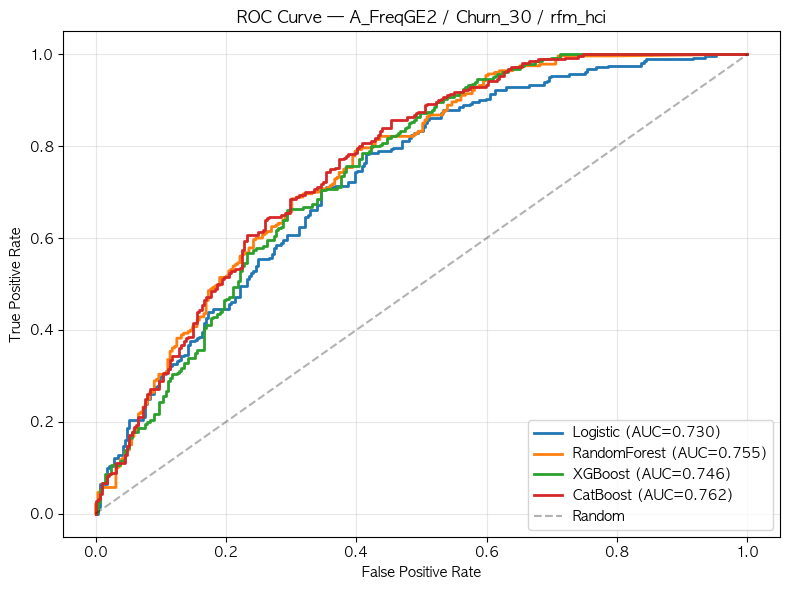

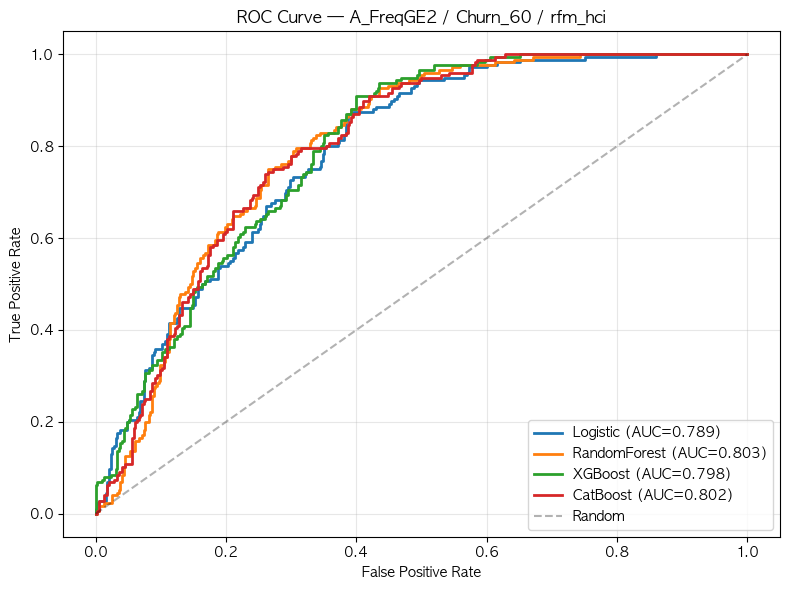

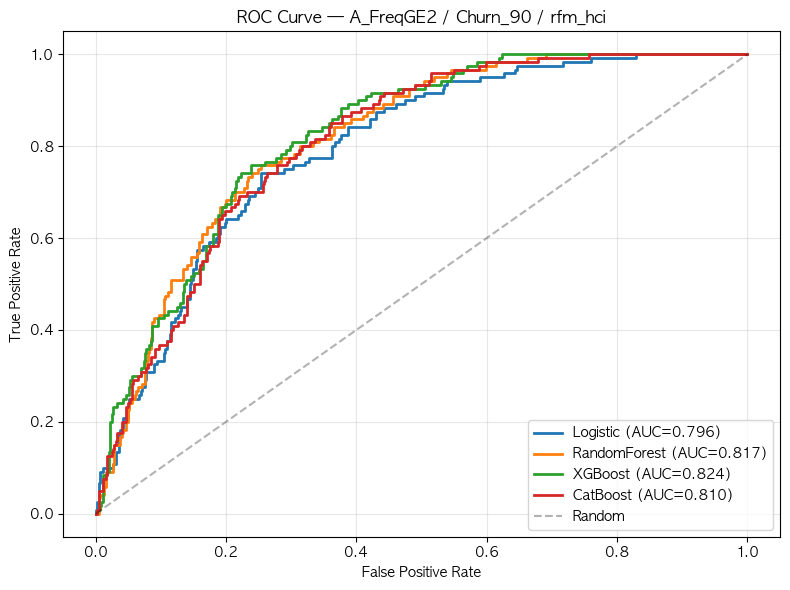

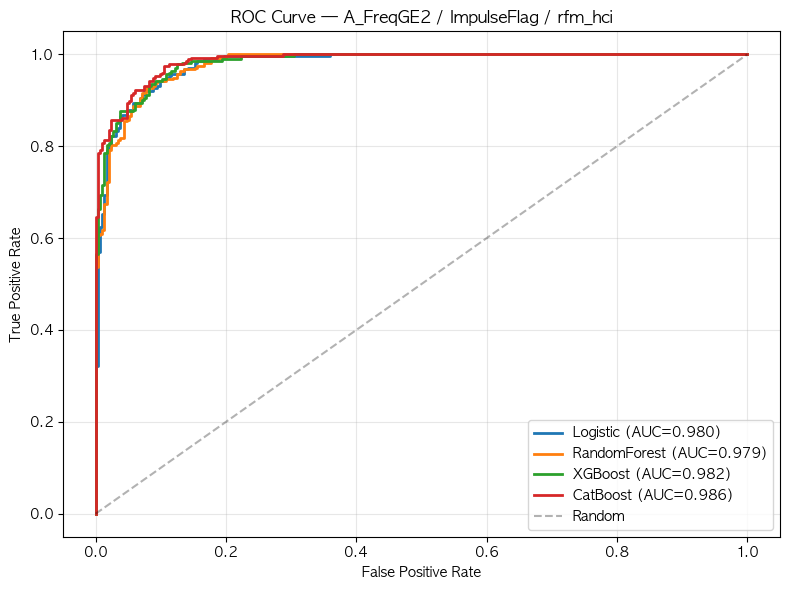

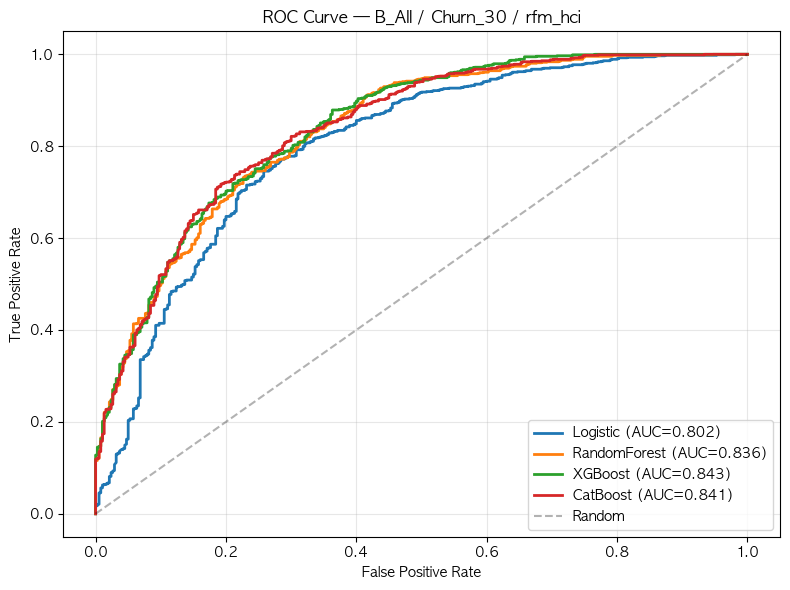

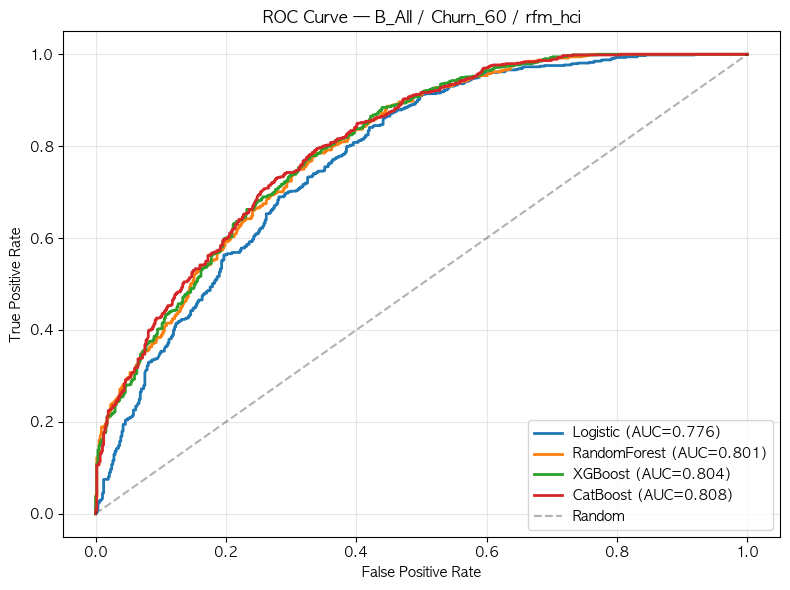

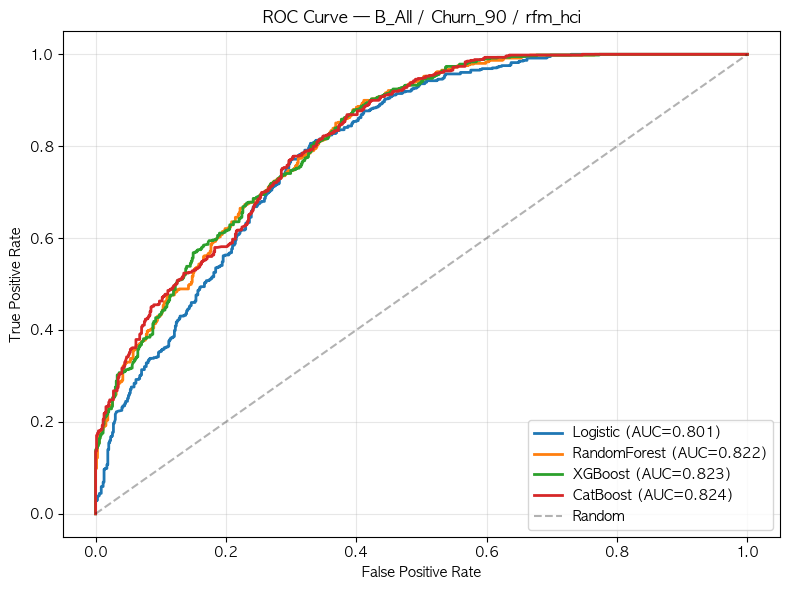

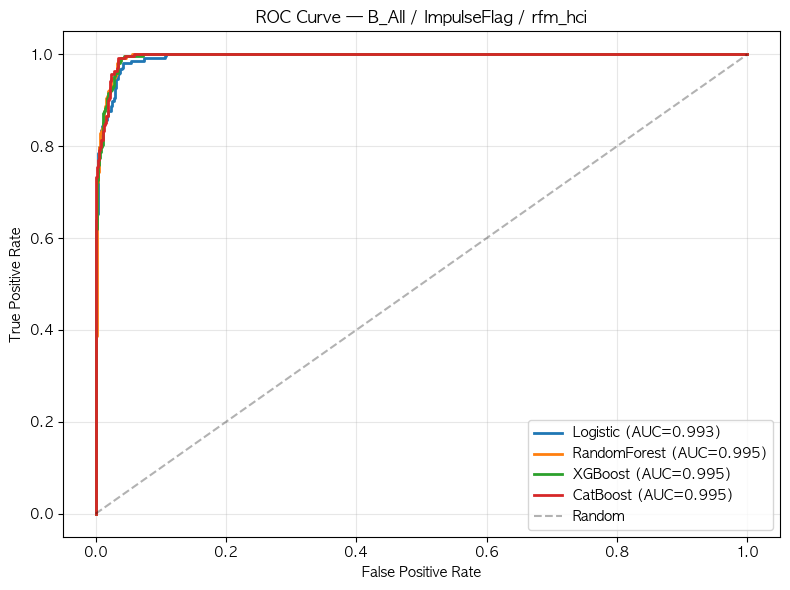

In [25]:
# ROC Curve 시각화

def plot_roc_curves(results_detail, dataset_name, target, feature_set='rfm_hci'):
    fig, ax = plt.subplots(figsize=(8, 6))
    for model_name in get_model_names():
        key = f"{dataset_name}_{feature_set}_{model_name}_{target}"
        if key in results_detail:
            d = results_detail[key]
            fpr, tpr, _ = roc_curve(d['y_test'], d['y_proba'])
            auc_val = roc_auc_score(d['y_test'], d['y_proba'])
            ax.plot(fpr, tpr, label=f"{model_name} (AUC={auc_val:.3f})", linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {dataset_name} / {target} / {feature_set}')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'roc_{dataset_name}_{target}_{feature_set}.png', dpi=150)
    plt.show()

for ds in datasets.keys():
    for target in targets:
        plot_roc_curves(results_detail, ds, target, 'rfm_hci')


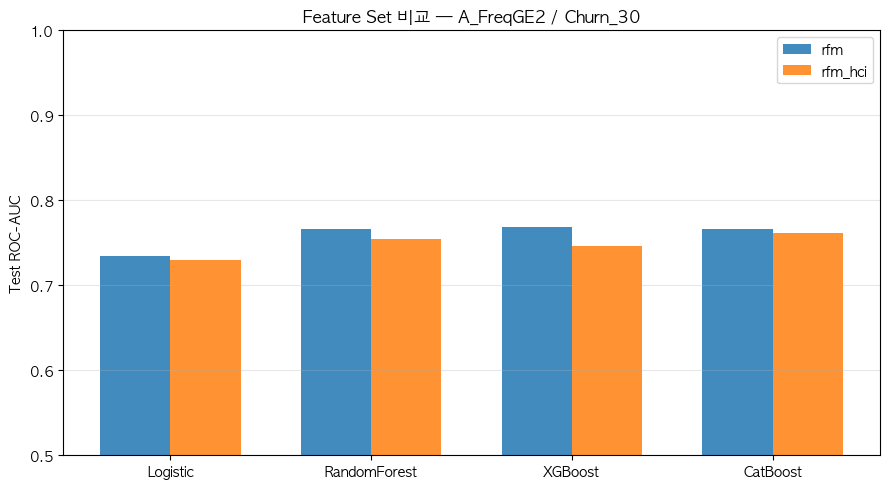

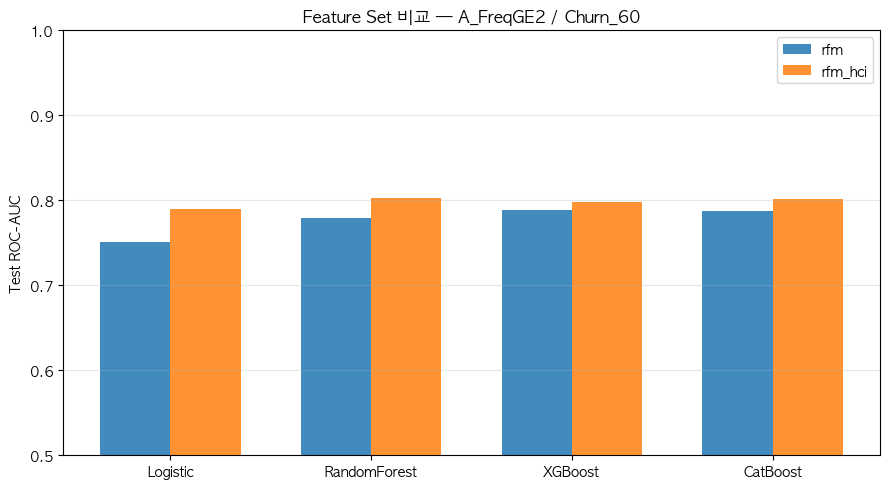

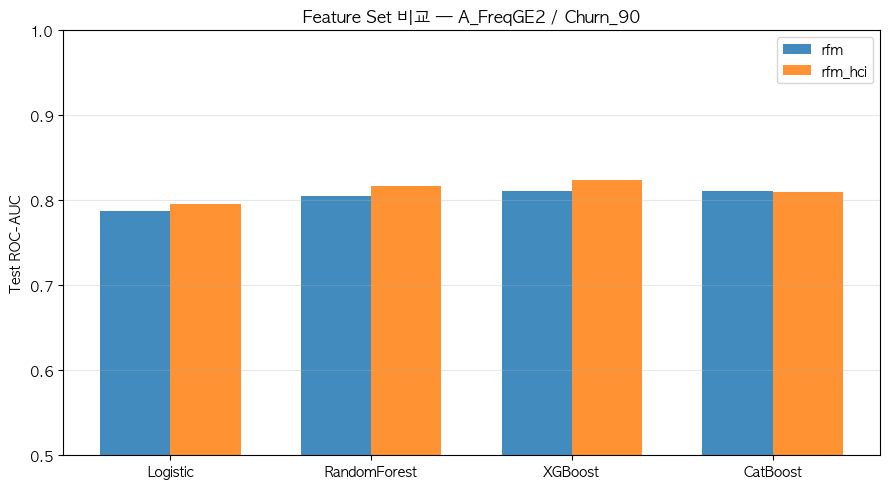

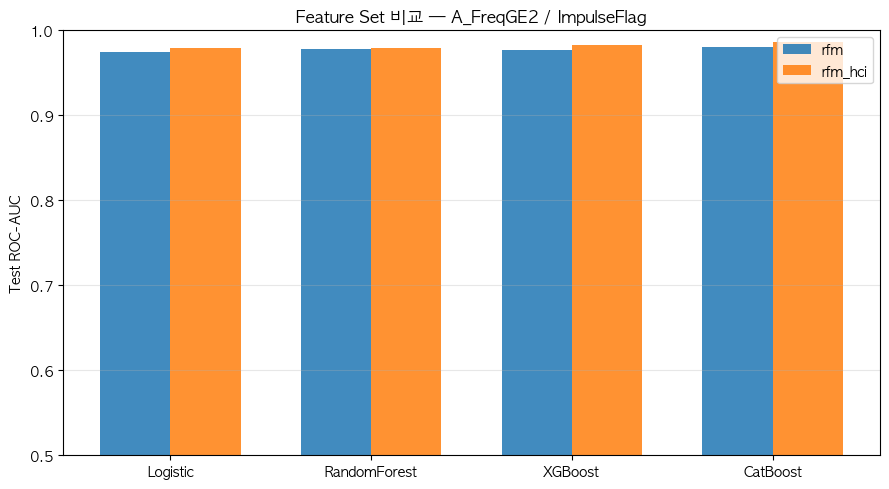

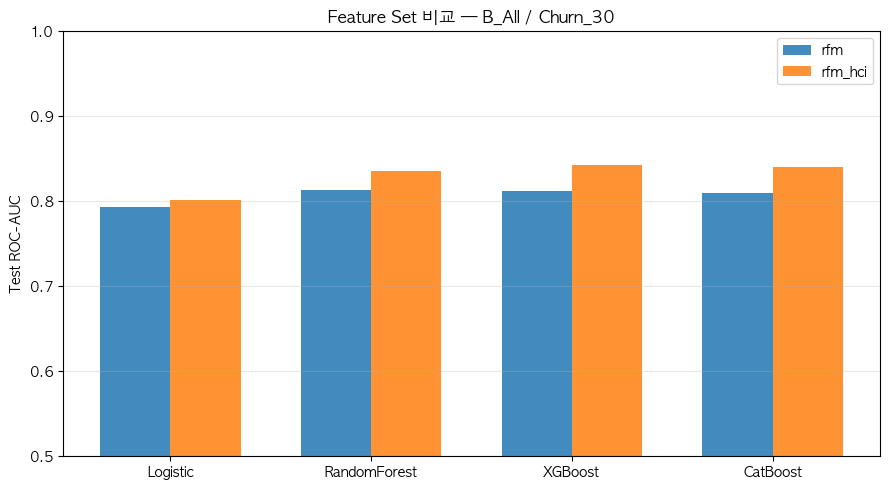

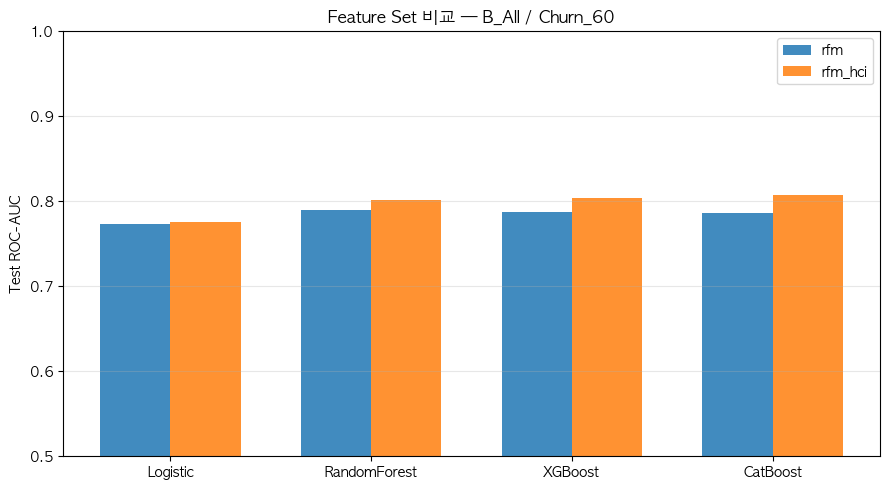

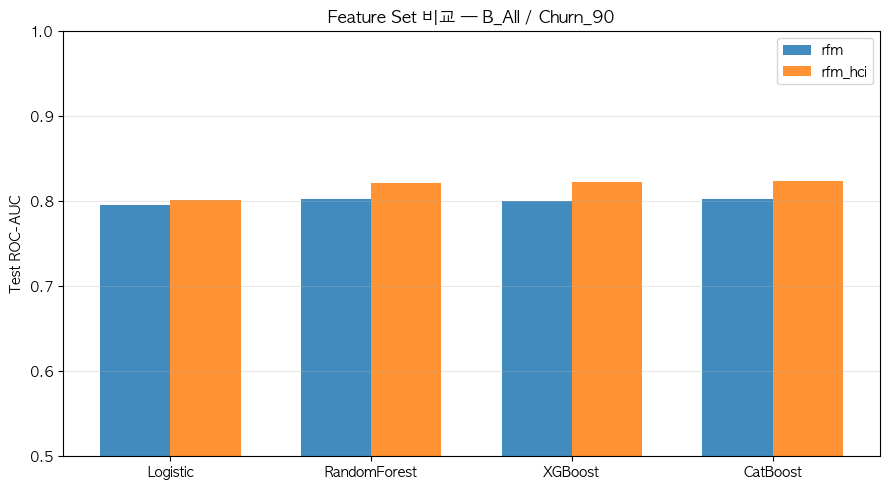

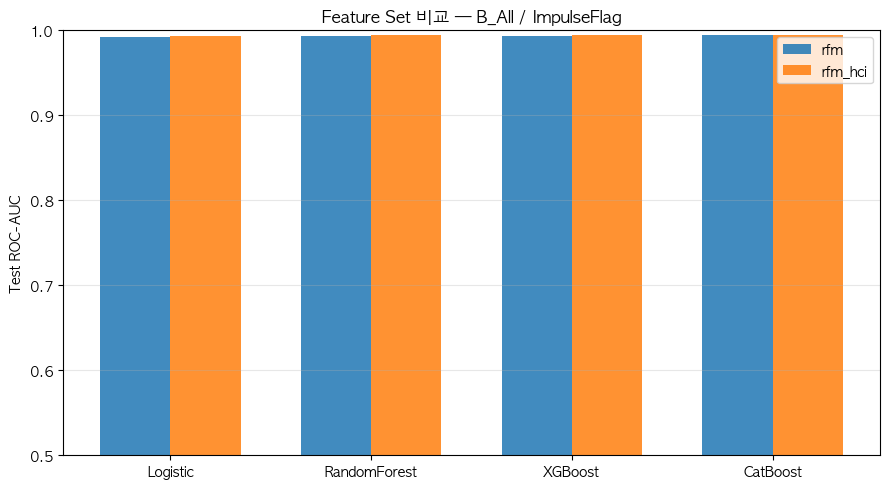

In [26]:
# Feature Set 효과 비교 시각화

def plot_feature_set_comparison(results_df, dataset_name, target):
    subset = results_df[
        (results_df['Dataset'] == dataset_name) & (results_df['Target'] == target)
    ]
    fig, ax = plt.subplots(figsize=(9, 5))
    fs_order = ['rfm', 'rfm_hci']
    model_order = get_model_names()
    x = np.arange(len(model_order))
    width = 0.35

    for i, fs in enumerate(fs_order):
        fs_data = subset[subset['FeatureSet'] == fs]
        aucs = [fs_data[fs_data['Model'] == m]['Test_AUC'].values[0]
                if len(fs_data[fs_data['Model'] == m]) > 0 else 0
                for m in model_order]
        ax.bar(x + i * width, aucs, width, label=fs, alpha=0.85)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(model_order)
    ax.set_ylabel('Test ROC-AUC')
    ax.set_title(f'Feature Set 비교 — {dataset_name} / {target}')
    ax.legend()
    ax.set_ylim(0.5, 1.0)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'feature_set_comparison_{dataset_name}_{target}.png', dpi=150)
    plt.show()

for ds in datasets.keys():
    for target in targets:
        plot_feature_set_comparison(results_df, ds, target)


# shap 분석


★ Churn_30 최고 모델: B_All_rfm_hci_XGBoost_Churn_30 (Test AUC=0.8427)

SHAP 중요도 TOP 20 — B_All_rfm_hci_XGBoost_Churn_30
                    feature  mean_abs_shap
              Purchase_Span       0.437100
            Repurchase_Rate       0.356438
               Hour_Entropy       0.119203
     Basket_Diversity_Index       0.114693
             Avg_Unit_Price       0.098442
    Country_Trend_Alignment       0.094106
          DayOfWeek_Entropy       0.085603
                  Frequency       0.083537
                        AOV       0.074138
         New_Category_Ratio       0.066679
                   IPI_Mean       0.064307
                   Monetary       0.056578
  Top_Product_Concentration       0.055425
    Avg_Repurchase_Interval       0.055361
       Low_Price_Item_Ratio       0.051573
      Country_Purchase_Rank       0.041383
   Max_Single_Order_Revenue       0.039195
             Preferred_Hour       0.038408
Avg_Unique_Items_per_Basket       0.038228
             Price_Var

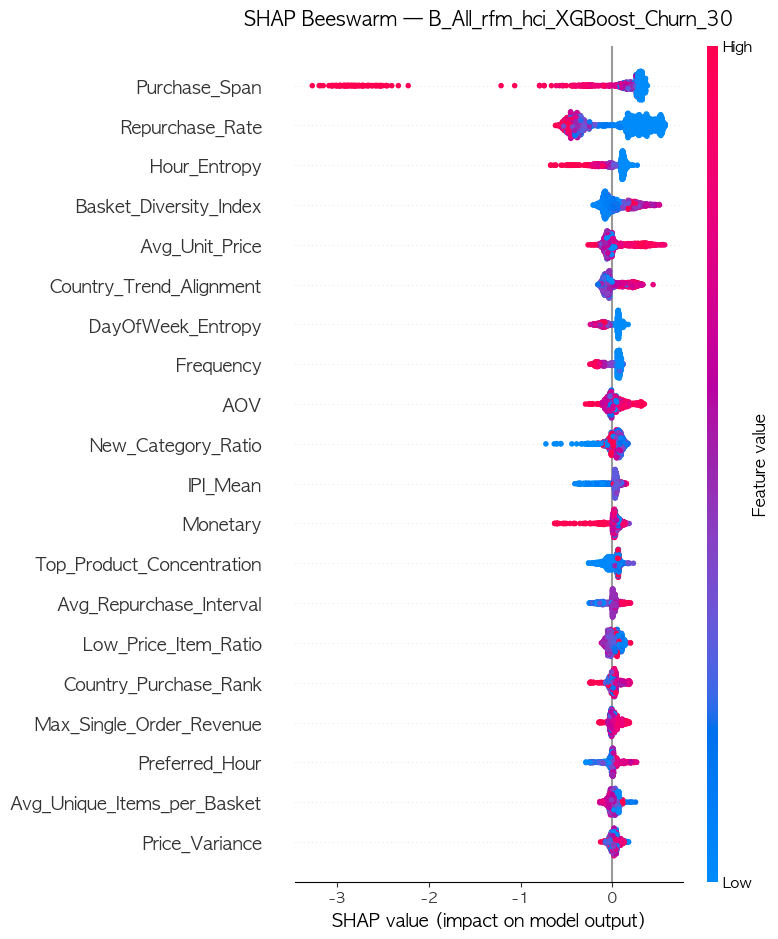

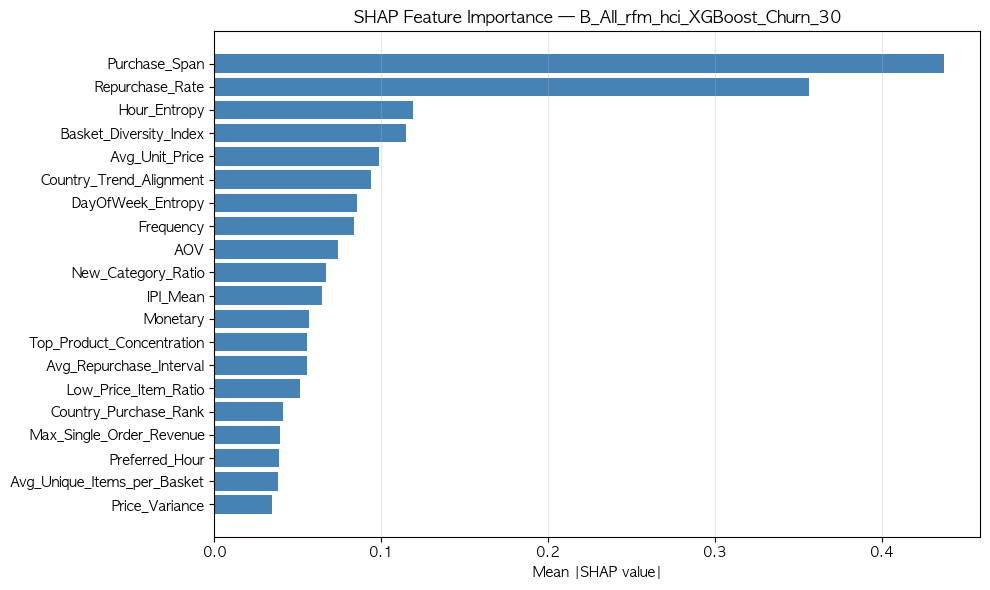


★ Churn_60 최고 모델: B_All_rfm_hci_CatBoost_Churn_60 (Test AUC=0.8075)

SHAP 중요도 TOP 20 — B_All_rfm_hci_CatBoost_Churn_60
                    feature  mean_abs_shap
              Purchase_Span       0.698300
            Repurchase_Rate       0.258349
     Basket_Diversity_Index       0.167616
             Avg_Unit_Price       0.162885
                  Frequency       0.152220
    Country_Trend_Alignment       0.099489
       Low_Price_Item_Ratio       0.097943
          DayOfWeek_Entropy       0.092593
                   IPI_Mean       0.087814
      Country_Purchase_Rank       0.077661
               Hour_Entropy       0.077091
        Avg_Items_per_Order       0.073702
             Price_Variance       0.069382
         New_Category_Ratio       0.067656
  Top_Product_Concentration       0.054855
Avg_Unique_Items_per_Basket       0.051778
             Preferred_Hour       0.042384
    Avg_Repurchase_Interval       0.041805
                        AOV       0.041097
                   M

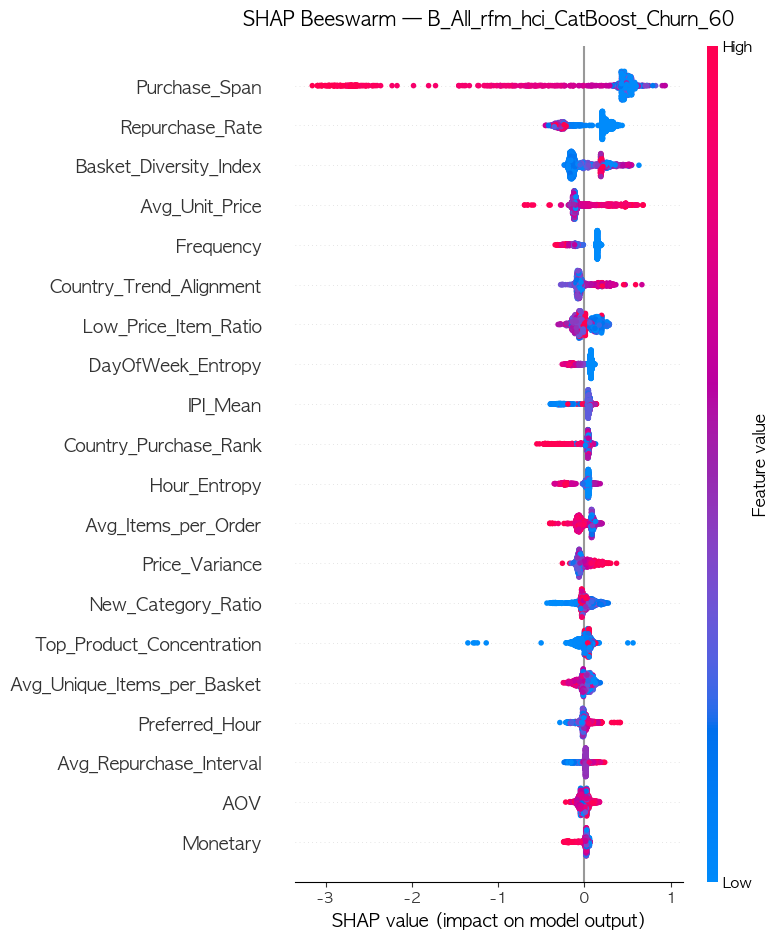

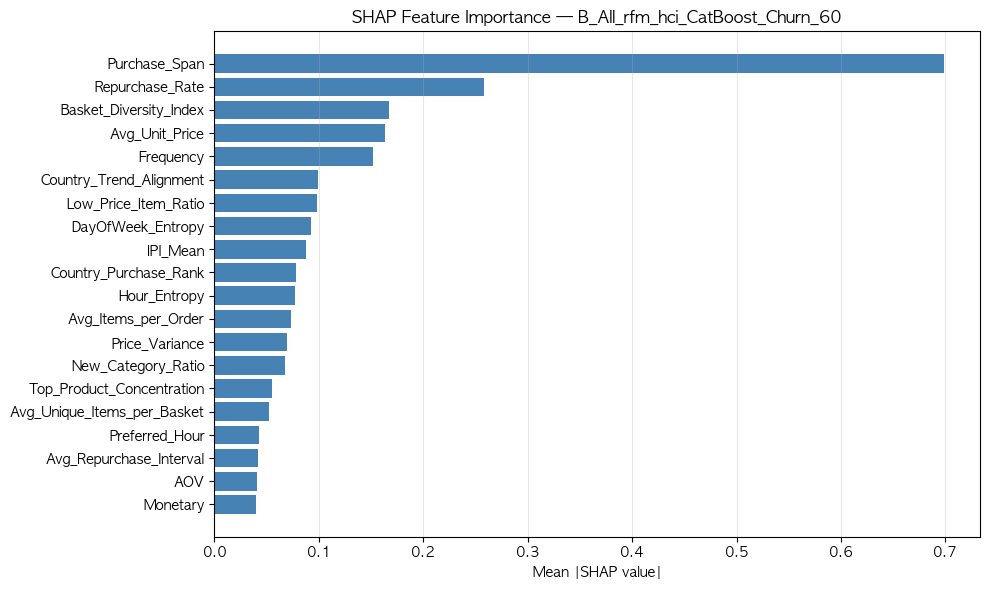


★ Churn_90 최고 모델: A_FreqGE2_rfm_hci_XGBoost_Churn_90 (Test AUC=0.8237)

SHAP 중요도 TOP 20 — A_FreqGE2_rfm_hci_XGBoost_Churn_90
                    feature  mean_abs_shap
              Purchase_Span       1.362303
               Hour_Entropy       0.131882
          DayOfWeek_Entropy       0.117026
         New_Category_Ratio       0.116101
                   IPI_Mean       0.102675
Avg_Unique_Items_per_Basket       0.093351
     Basket_Diversity_Index       0.078497
              Active_Months       0.074462
        Avg_Items_per_Order       0.068084
       Low_Price_Item_Ratio       0.066858
  Top_Product_Concentration       0.066645
    Avg_Repurchase_Interval       0.062960
             Avg_Unit_Price       0.062189
                   Monetary       0.050362
    Days_to_Return_Purchase       0.048365
                  Frequency       0.046851
 Category_Concentration_Std       0.044181
    Country_Trend_Alignment       0.030101
        Revenue_Consistency       0.026059
              

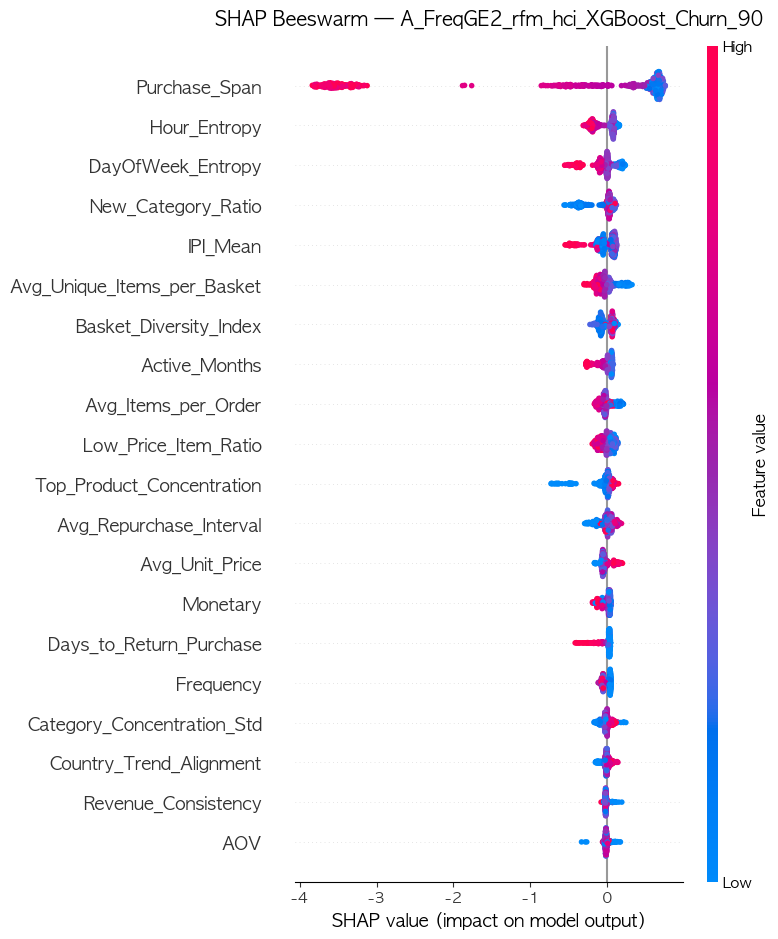

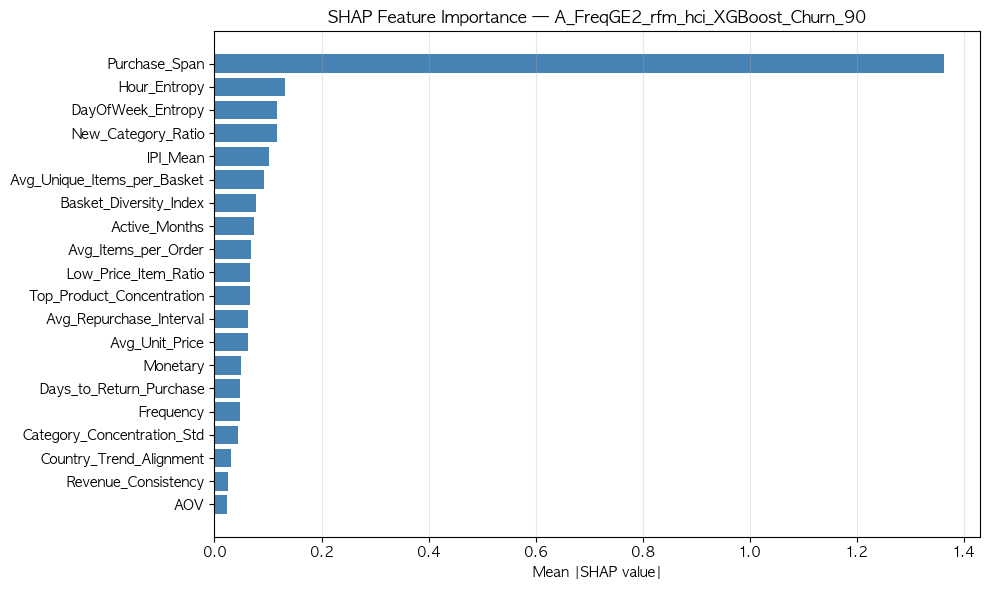


★ ImpulseFlag 최고 모델: B_All_rfm_hci_CatBoost_ImpulseFlag (Test AUC=0.9951)

SHAP 중요도 TOP 20 — B_All_rfm_hci_CatBoost_ImpulseFlag
                    feature  mean_abs_shap
        Revenue_Consistency       2.726490
                  Frequency       1.432137
              Active_Months       0.430237
              Purchase_Span       0.284250
          DayOfWeek_Entropy       0.218624
      Country_Purchase_Rank       0.208611
               Hour_Entropy       0.170317
            Repurchase_Rate       0.169512
                    IPI_Std       0.167565
                   IPI_Mean       0.156798
                   Monetary       0.149303
  Top_Product_Concentration       0.145934
    Country_Trend_Alignment       0.103108
 Category_Concentration_Std       0.098490
      Purchase_Rhythm_Score       0.089820
Avg_Unique_Items_per_Basket       0.087696
              Weekend_Ratio       0.079845
                    Recency       0.074144
                CV_Interval       0.061668
          C

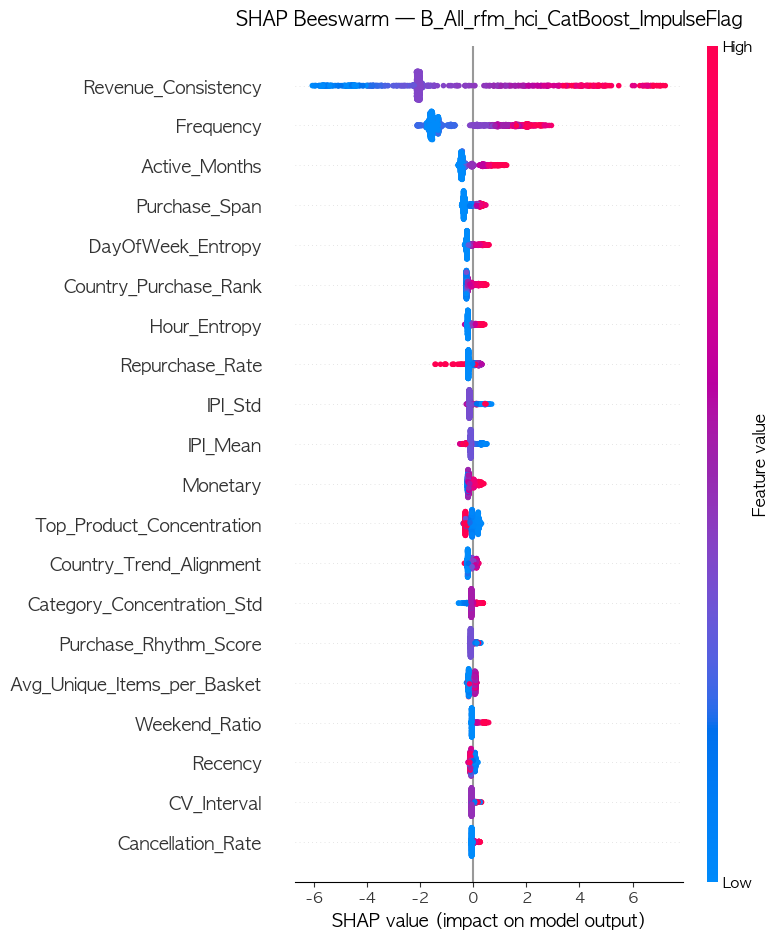

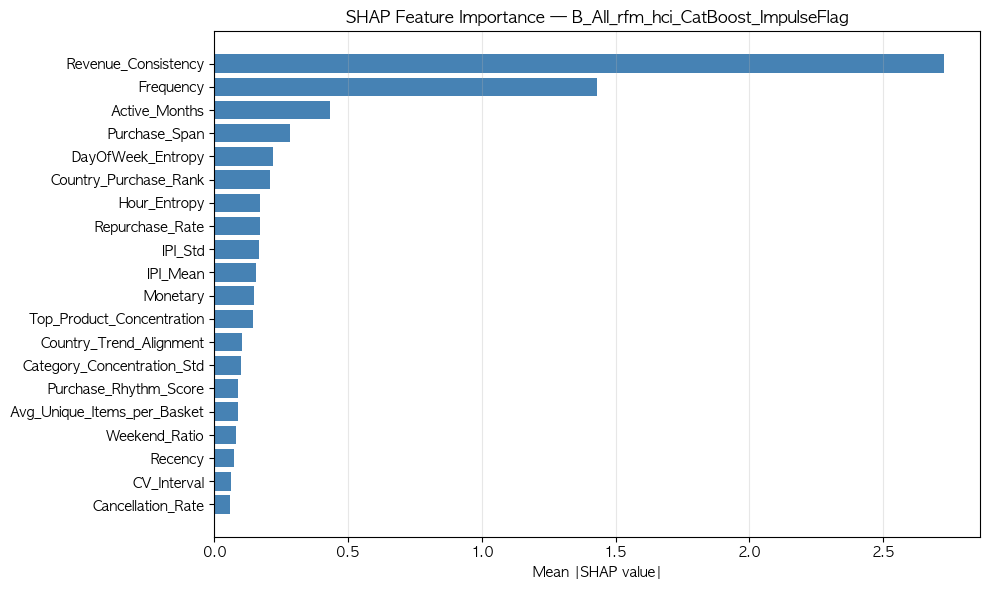

In [28]:
# SHAP 분석 (RFM+HCI 기준 최고 성능 모델)

def run_shap_analysis(results_detail, exp_key, top_n=20):
    d = results_detail[exp_key]
    X_test_df = pd.DataFrame(d['X_test_sc'], columns=d['feature_cols'])

    model = d['model']
    if isinstance(model, XGBClassifier):
        # XGBoost 내장 SHAP (버전 호환 문제 우회)
        booster = model.get_booster()
        import xgboost as xgb
        dmat = xgb.DMatrix(X_test_df)
        shap_arr = booster.predict(dmat, pred_contribs=True)[:, :-1]
    elif isinstance(model, LogisticRegression):
        explainer = shap.LinearExplainer(model, X_test_df)
        shap_values = explainer(X_test_df)
        shap_arr = shap_values.values
    else:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_df)
        shap_arr = shap_values[1] if isinstance(shap_values, list) else shap_values

    mean_abs = np.mean(np.abs(shap_arr), axis=0)
    shap_importance = pd.DataFrame({
        'feature': d['feature_cols'],
        'mean_abs_shap': mean_abs
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    print(f"\n{'='*50}")
    print(f"SHAP 중요도 TOP {top_n} — {exp_key}")
    print(f"{'='*50}")
    print(shap_importance.head(top_n).to_string(index=False))

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_arr, X_test_df, plot_type="dot",
                      max_display=top_n, show=False)
    plt.title(f"SHAP Beeswarm — {exp_key}", fontsize=14, pad=15)
    plt.tight_layout()
    plt.savefig(f'shap_beeswarm_{exp_key}.png', dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10, 6))
    top = shap_importance.head(top_n)
    plt.barh(top['feature'][::-1], top['mean_abs_shap'][::-1], color='steelblue')
    plt.xlabel('Mean |SHAP value|')
    plt.title(f"SHAP Feature Importance — {exp_key}")
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'shap_bar_{exp_key}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return shap_importance, shap_arr, X_test_df


shap_results = {}
for target in targets:
    subset = results_df[
        (results_df['Target'] == target) & (results_df['FeatureSet'] == 'rfm_hci')
    ]
    best_idx = subset['Test_AUC'].idxmax()
    best = subset.loc[best_idx]
    best_key = f"{best['Dataset']}_rfm_hci_{best['Model']}_{target}"

    print(f"\n★ {target} 최고 모델: {best_key} (Test AUC={best['Test_AUC']:.4f})")
    shap_imp, shap_arr, X_test_shap = run_shap_analysis(results_detail, best_key)
    shap_results[target] = {
        'key': best_key, 'importance': shap_imp,
        'shap_arr': shap_arr, 'X_test': X_test_shap
    }



넛지 유형별 SHAP 기여도 (Churn_30):
                   sum      mean  count
nudge_type                             
RFM_baseline  0.721383  0.103055      7
유도성           0.467224  0.155741      3
타성            0.366342  0.045793      8
긍정성           0.258515  0.036931      7
인지적효율성        0.200331  0.050083      4
비교성           0.140131  0.046710      3
흥미성           0.066679  0.066679      1
일관성           0.010593  0.010593      1


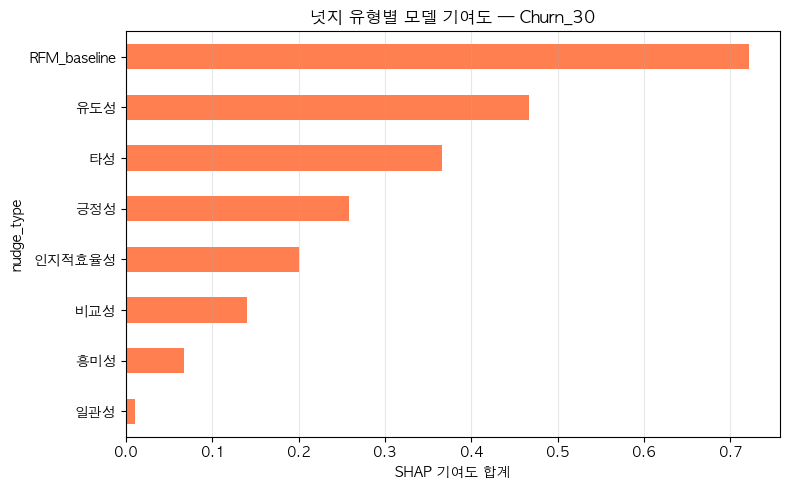


넛지 유형별 SHAP 기여도 (Churn_60):
                   sum      mean  count
nudge_type                             
RFM_baseline  1.056361  0.150909      7
긍정성           0.386951  0.055279      7
타성            0.368867  0.046108      8
유도성           0.355009  0.118336      3
인지적효율성        0.263927  0.065982      4
비교성           0.182210  0.060737      3
흥미성           0.067656  0.067656      1
일관성           0.014263  0.014263      1


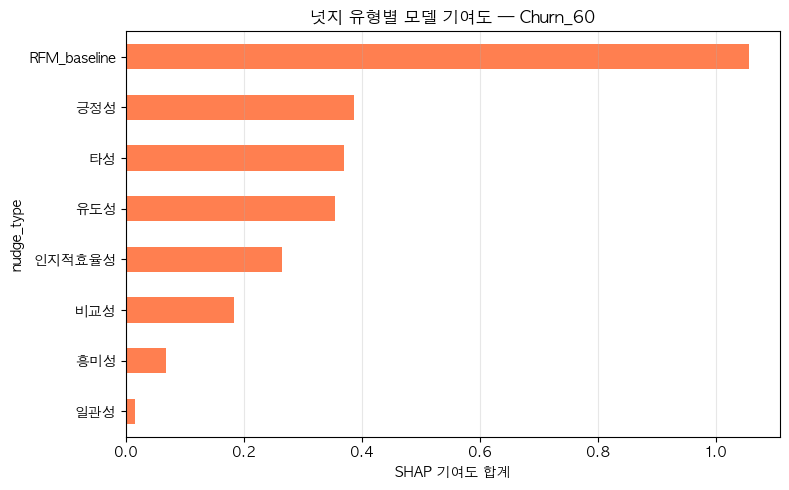


넛지 유형별 SHAP 기여도 (Churn_90):
                   sum      mean  count
nudge_type                             
RFM_baseline  1.651927  0.235990      7
타성            0.412630  0.051579      8
긍정성           0.215386  0.030769      7
인지적효율성        0.199633  0.049908      4
유도성           0.146488  0.048829      3
흥미성           0.116101  0.116101      1
비교성           0.047023  0.015674      3
일관성           0.044181  0.044181      1


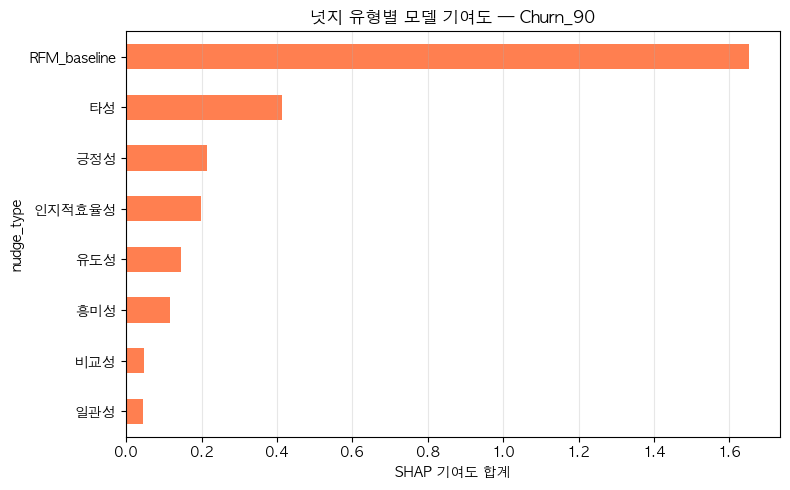


넛지 유형별 SHAP 기여도 (ImpulseFlag):
                   sum      mean  count
nudge_type                             
RFM_baseline  5.122411  0.731773      7
타성            0.975601  0.121950      8
유도성           0.350021  0.116674      3
비교성           0.320526  0.106842      3
긍정성           0.223873  0.031982      7
인지적효율성        0.143782  0.047927      3
일관성           0.098490  0.098490      1


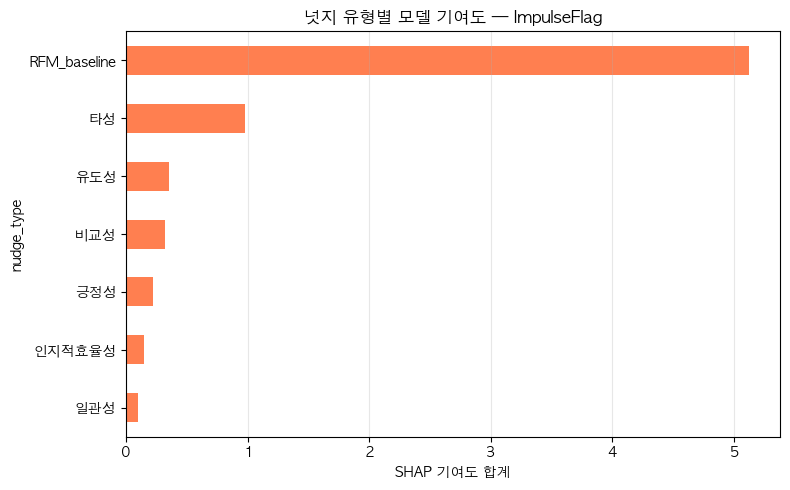

In [29]:
# 넛지 유형별 SHAP 기여도 집계

def aggregate_shap_by_nudge(shap_importance, target_name=""):
    var_to_nudge = {}
    for nudge, vars in FEATURE_GROUPS.items():
        for v in vars:
            var_to_nudge[v] = nudge

    df = shap_importance.copy()
    df['nudge_type'] = df['feature'].map(var_to_nudge).fillna('기타')

    nudge_agg = df.groupby('nudge_type')['mean_abs_shap'].agg(
        ['sum', 'mean', 'count']
    ).sort_values('sum', ascending=False)

    print(f"\n넛지 유형별 SHAP 기여도 ({target_name}):")
    print(nudge_agg.to_string())

    fig, ax = plt.subplots(figsize=(8, 5))
    nudge_agg['sum'].sort_values().plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('SHAP 기여도 합계')
    ax.set_title(f'넛지 유형별 모델 기여도 — {target_name}')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'shap_nudge_contribution_{target_name}.png', dpi=150)
    plt.show()

    return nudge_agg

for target in targets:
    aggregate_shap_by_nudge(shap_results[target]['importance'], target)


# 최종 확인

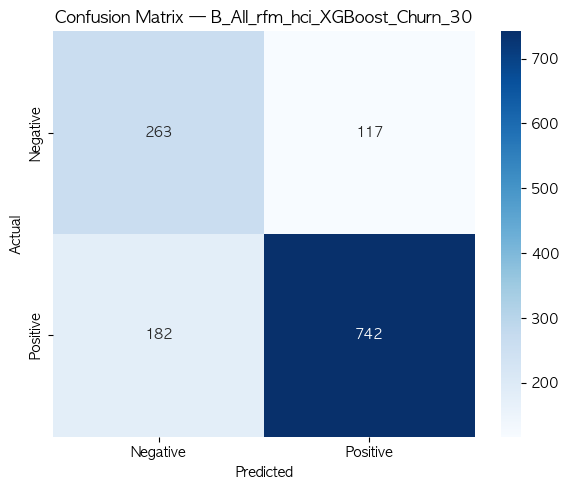

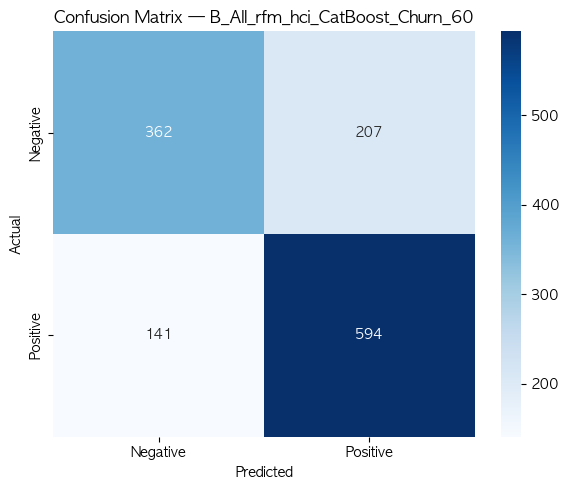

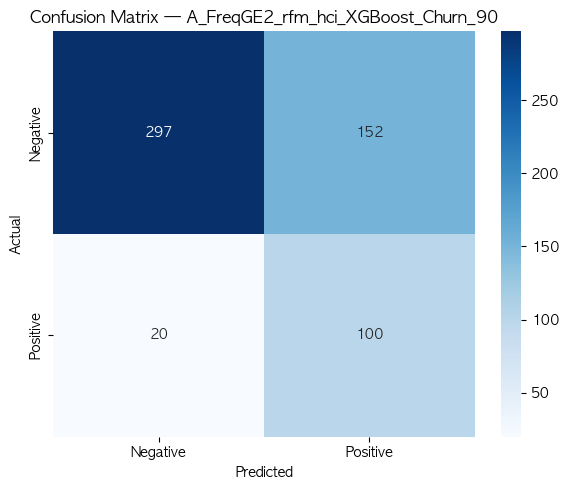

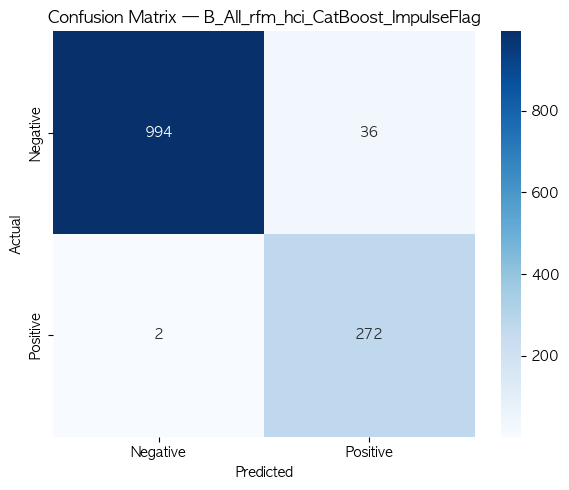

In [31]:
# Confusion Matrix (최고 모델)
def plot_confusion_matrix(results_detail, exp_key):
    d = results_detail[exp_key]
    cm = confusion_matrix(d['y_test'], d['y_pred'])
 
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {exp_key}')
    plt.tight_layout()
    plt.savefig(f'confusion_{exp_key}.png', dpi=150)
    plt.show()
 
for target in targets:
    plot_confusion_matrix(results_detail, shap_results[target]['key'])
 

In [32]:
# 최종 리포트
print("\n" + "=" * 60)
print("✅ 모든 실험 완료!")
print("=" * 60)

for target in targets:
    key = shap_results[target]['key']
    d = results_detail[key]
    print(f"\n{'─'*50}")
    print(f"Classification Report — {key}")
    print(f"{'─'*50}")
    print(classification_report(d['y_test'], d['y_pred']))

print("""
저장된 파일:
  - experiment_results.csv              : 64개 실험의 test 성능 및 best hyperparameter
  - experiment_split_metrics.csv        : Training / Validation / Test 5개 지표 비교표
  - roc_*.png                           : ROC 커브
  - feature_set_comparison_*.png        : RFM vs RFM+HCI 비교 차트
  - shap_beeswarm_*.png                 : SHAP Beeswarm Plot
  - shap_bar_*.png                      : SHAP Bar Plot
  - shap_nudge_contribution_*.png       : 넛지 유형별 기여도
  - confusion_*.png                     : Confusion Matrix
""")



✅ 모든 실험 완료!

──────────────────────────────────────────────────
Classification Report — B_All_rfm_hci_XGBoost_Churn_30
──────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.59      0.69      0.64       380
           1       0.86      0.80      0.83       924

    accuracy                           0.77      1304
   macro avg       0.73      0.75      0.73      1304
weighted avg       0.78      0.77      0.78      1304


──────────────────────────────────────────────────
Classification Report — B_All_rfm_hci_CatBoost_Churn_60
──────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.72      0.64      0.68       569
           1       0.74      0.81      0.77       735

    accuracy                           0.73      1304
   macro avg       0.73      0.72      0.72      1304
weighted avg       0.73      0.73      0.73      1304


───────────────

# 추가 비교 실험

기존 baseline 실험은 유지하고, 아래 셀에서 컬럼 제거 variant를 별도로 실행한다.


In [34]:
# 추가 비교 실험 helper
from pathlib import Path

VARIANT_CONFIG_PATH = 'experiment_missing_columns.json'
VARIANT_RESULT_PATH = 'experiment_results_variants.csv'
VARIANT_SPLIT_RESULT_PATH = 'experiment_split_metrics_variants.csv'
VARIANT_COMPARISON_PATH = 'experiment_variant_comparison.csv'
TEST_METRIC_COLS = ['Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_AUC']


def load_variant_config(path=VARIANT_CONFIG_PATH):
    cfg_path = Path(path)
    if not cfg_path.exists():
        raise FileNotFoundError(
            f'{path} 파일이 없습니다. Processing_final.ipynb의 추가 메타데이터 저장 셀을 먼저 실행하세요.'
        )
    return json.loads(cfg_path.read_text())


def drop_columns_from_feature_sets(base_feature_sets, drop_cols):
    drop_cols = set(drop_cols)
    return {
        name: [c for c in cols if c not in drop_cols]
        for name, cols in base_feature_sets.items()
    }


def build_variant_specs(variant_config):
    return [
        {
            'Scenario': 'B_drop_selected_cols',
            'Description': 'B dataset에서 IPI_Mean, Revenue_Consistency, Price_Variance 제거',
            'DatasetDropCols': variant_config['manual_drop_variants']['B_drop_selected_cols'],
        },
        {
            'Scenario': 'drop_missing_ge_50pct',
            'Description': '결측 대체 전 결측률 50% 이상 컬럼 제거',
            'DatasetDropCols': variant_config['prefill_missing_ge_50pct'],
        },
    ]


def run_variant_experiments(base_datasets, targets, base_feature_sets, variant_specs, n_trials=N_TRIALS):
    results_list = []
    split_list = []
    detail_dict = {}

    for spec in variant_specs:
        print('\n' + '=' * 60)
        print(f"추가 실험: {spec['Scenario']}")
        print(spec['Description'])
        print('=' * 60)

        for ds_name, drop_cols in spec['DatasetDropCols'].items():
            if ds_name not in base_datasets:
                print(f'  ⚠️ {ds_name} 데이터셋이 없어 건너뜁니다.')
                continue

            variant_feature_sets = drop_columns_from_feature_sets(base_feature_sets, drop_cols)
            variant_results, variant_splits, variant_details = run_all_experiments(
                {ds_name: base_datasets[ds_name]},
                targets,
                variant_feature_sets,
                verbose=True,
                n_trials=n_trials,
            )

            variant_results.insert(0, 'Scenario', spec['Scenario'])
            variant_results.insert(1, 'VariantDescription', spec['Description'])
            variant_results['DroppedColumns'] = ', '.join(drop_cols)
            variant_results['DroppedColumnCount'] = len(drop_cols)
            variant_results['Experiment'] = variant_results['Experiment'].map(
                lambda x: f"{spec['Scenario']}::{x}"
            )

            variant_splits.insert(0, 'Scenario', spec['Scenario'])
            variant_splits['DroppedColumns'] = ', '.join(drop_cols)
            variant_splits['DroppedColumnCount'] = len(drop_cols)
            variant_splits['Experiment'] = variant_splits['Experiment'].map(
                lambda x: f"{spec['Scenario']}::{x}"
            )

            for old_key, value in variant_details.items():
                detail_dict[f"{spec['Scenario']}::{old_key}"] = value

            results_list.append(variant_results)
            split_list.append(variant_splits)

            print(f"  [{ds_name}] 제거 컬럼: {drop_cols if drop_cols else '없음'}")
            print(f"  [{ds_name}] feature counts: "
                  f"rfm={len(variant_feature_sets['rfm'])}, "
                  f"rfm_hci={len(variant_feature_sets['rfm_hci'])}")

    results_df_variant = pd.concat(results_list, ignore_index=True)
    split_df_variant = pd.concat(split_list, ignore_index=True)
    return results_df_variant, split_df_variant, detail_dict


def build_variant_comparison(baseline_results, variant_results):
    baseline_cols = ['Dataset', 'Target', 'FeatureSet', 'Model', 'FeatureCount', 'RemovedLeakageCols'] + TEST_METRIC_COLS
    baseline = baseline_results[baseline_cols].copy()

    comparison = variant_results.merge(
        baseline,
        on=['Dataset', 'Target', 'FeatureSet', 'Model'],
        how='left',
        suffixes=('_variant', '_baseline'),
    )

    for metric in TEST_METRIC_COLS:
        base_name = f'{metric}_baseline'
        var_name = f'{metric}_variant'
        delta_name = f"Delta_{metric.replace('Test_', '')}"
        comparison[delta_name] = comparison[var_name] - comparison[base_name]

    return comparison


In [35]:
# 추가 비교 실험 실행
variant_config = load_variant_config()
variant_specs = build_variant_specs(variant_config)

variant_results_df, variant_split_metrics_df, variant_results_detail = run_variant_experiments(
    datasets,
    TARGETS,
    feature_sets,
    variant_specs,
    n_trials=N_TRIALS,
)

variant_results_df.to_csv(VARIANT_RESULT_PATH, index=False)
variant_split_metrics_df.to_csv(VARIANT_SPLIT_RESULT_PATH, index=False)

variant_comparison_df = build_variant_comparison(results_df, variant_results_df)
variant_comparison_df.to_csv(VARIANT_COMPARISON_PATH, index=False)

print('\n✅ 추가 실험 결과 저장 완료')
print(f'  - {VARIANT_RESULT_PATH}')
print(f'  - {VARIANT_SPLIT_RESULT_PATH}')
print(f'  - {VARIANT_COMPARISON_PATH}')



추가 실험: B_drop_selected_cols
B dataset에서 IPI_Mean, Revenue_Consistency, Price_Variance 제거
  실행 중: B_All_rfm_Logistic_Churn_30
  실행 중: B_All_rfm_RandomForest_Churn_30
  실행 중: B_All_rfm_XGBoost_Churn_30
  실행 중: B_All_rfm_CatBoost_Churn_30
  실행 중: B_All_rfm_hci_Logistic_Churn_30
  실행 중: B_All_rfm_hci_RandomForest_Churn_30
  실행 중: B_All_rfm_hci_XGBoost_Churn_30
  실행 중: B_All_rfm_hci_CatBoost_Churn_30
  실행 중: B_All_rfm_Logistic_Churn_60
  실행 중: B_All_rfm_RandomForest_Churn_60
  실행 중: B_All_rfm_XGBoost_Churn_60
  실행 중: B_All_rfm_CatBoost_Churn_60
  실행 중: B_All_rfm_hci_Logistic_Churn_60
  실행 중: B_All_rfm_hci_RandomForest_Churn_60
  실행 중: B_All_rfm_hci_XGBoost_Churn_60
  실행 중: B_All_rfm_hci_CatBoost_Churn_60
  실행 중: B_All_rfm_Logistic_Churn_90
  실행 중: B_All_rfm_RandomForest_Churn_90
  실행 중: B_All_rfm_XGBoost_Churn_90
  실행 중: B_All_rfm_CatBoost_Churn_90
  실행 중: B_All_rfm_hci_Logistic_Churn_90
  실행 중: B_All_rfm_hci_RandomForest_Churn_90
  실행 중: B_All_rfm_hci_XGBoost_Churn_90
  실행 중: B_All_rfm_hc

In [36]:
# 추가 비교 실험 요약
for scenario in variant_results_df['Scenario'].unique():
    print('\n' + '=' * 60)
    print(f'추가 실험 요약: {scenario}')
    print('=' * 60)

    subset = variant_comparison_df[variant_comparison_df['Scenario'] == scenario].copy()
    cols_to_show = [
        'Dataset', 'Target', 'FeatureSet', 'Model', 'DroppedColumns',
        'Test_AUC_baseline', 'Test_AUC_variant', 'Delta_AUC',
        'Test_F1_baseline', 'Test_F1_variant', 'Delta_F1',
    ]
    print(subset[cols_to_show].sort_values(
        ['Dataset', 'Target', 'FeatureSet', 'Model']
    ).round(4).to_string(index=False))



추가 실험 요약: B_drop_selected_cols
Dataset      Target FeatureSet        Model                                DroppedColumns  Test_AUC_baseline  Test_AUC_variant  Delta_AUC  Test_F1_baseline  Test_F1_variant  Delta_F1
  B_All    Churn_30        rfm     CatBoost IPI_Mean, Revenue_Consistency, Price_Variance             0.8092            0.8075    -0.0018            0.8132           0.8098   -0.0034
  B_All    Churn_30        rfm     Logistic IPI_Mean, Revenue_Consistency, Price_Variance             0.7932            0.7927    -0.0005            0.8062           0.8087    0.0025
  B_All    Churn_30        rfm RandomForest IPI_Mean, Revenue_Consistency, Price_Variance             0.8135            0.8088    -0.0047            0.8135           0.8198    0.0063
  B_All    Churn_30        rfm      XGBoost IPI_Mean, Revenue_Consistency, Price_Variance             0.8116            0.8132     0.0017            0.8081           0.8060   -0.0020
  B_All    Churn_30    rfm_hci     CatBoost IPI_Mean,

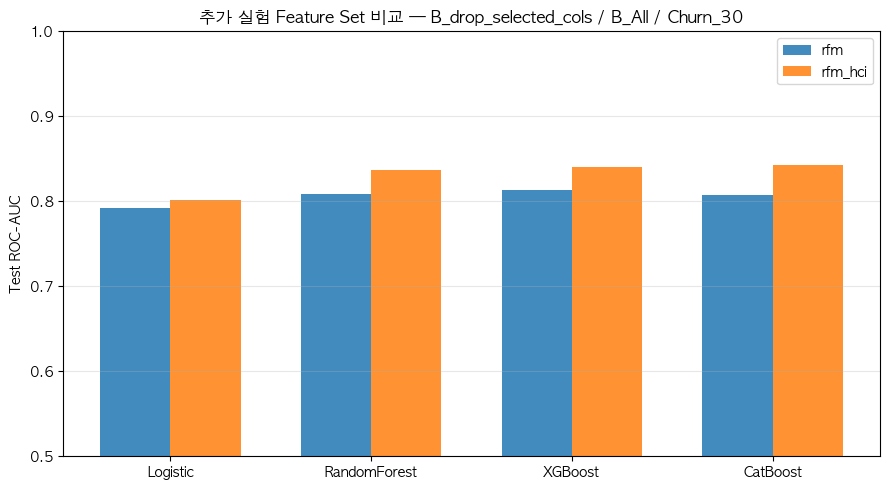

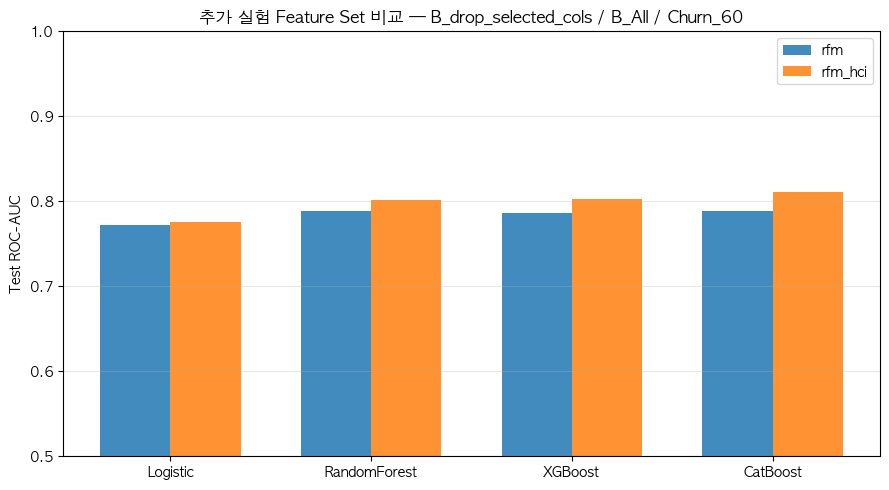

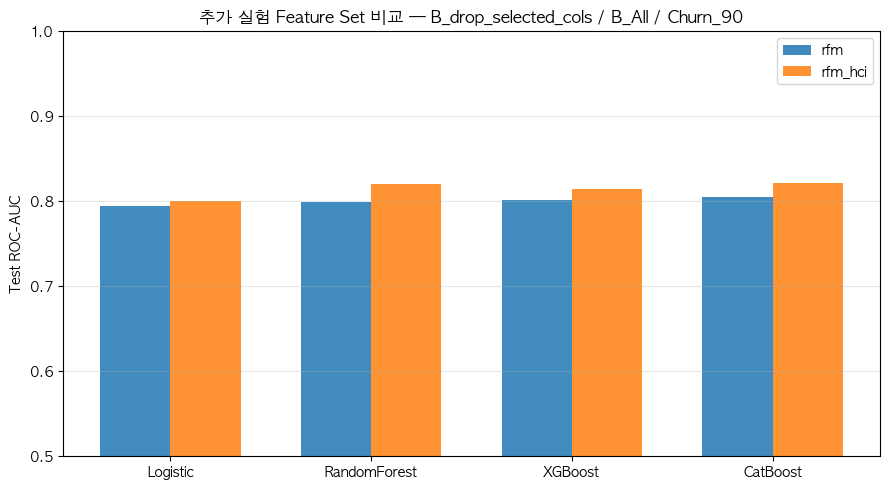

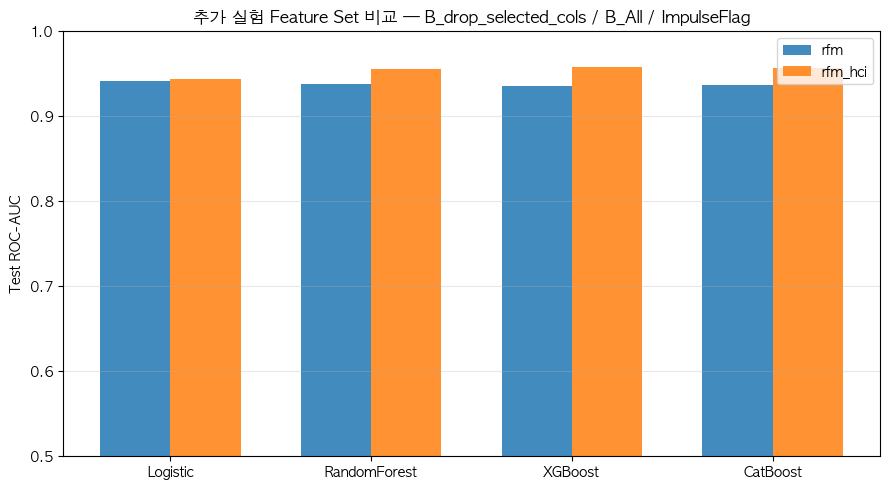

데이터 없음: B_drop_selected_cols / A_FreqGE2 / Churn_30
데이터 없음: B_drop_selected_cols / A_FreqGE2 / Churn_60
데이터 없음: B_drop_selected_cols / A_FreqGE2 / Churn_90
데이터 없음: B_drop_selected_cols / A_FreqGE2 / ImpulseFlag


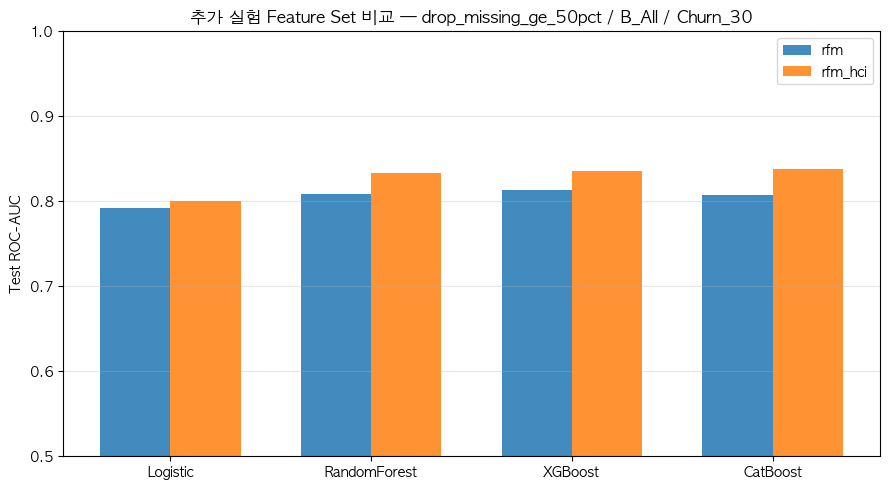

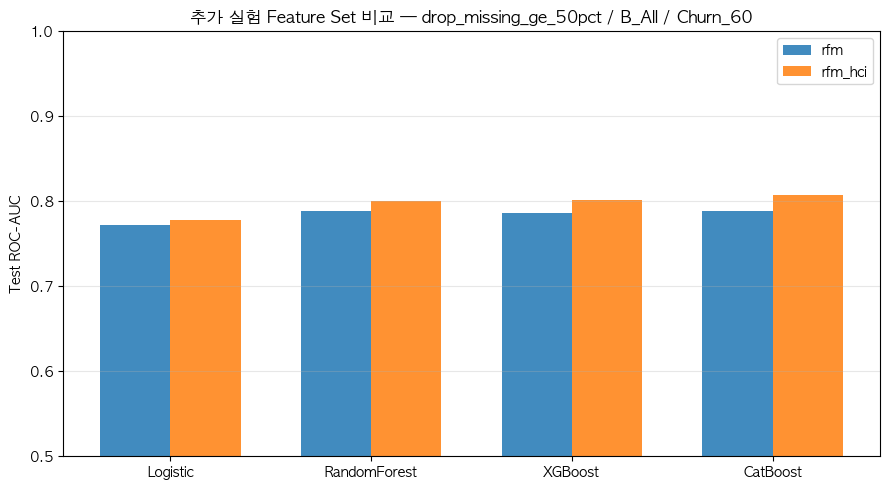

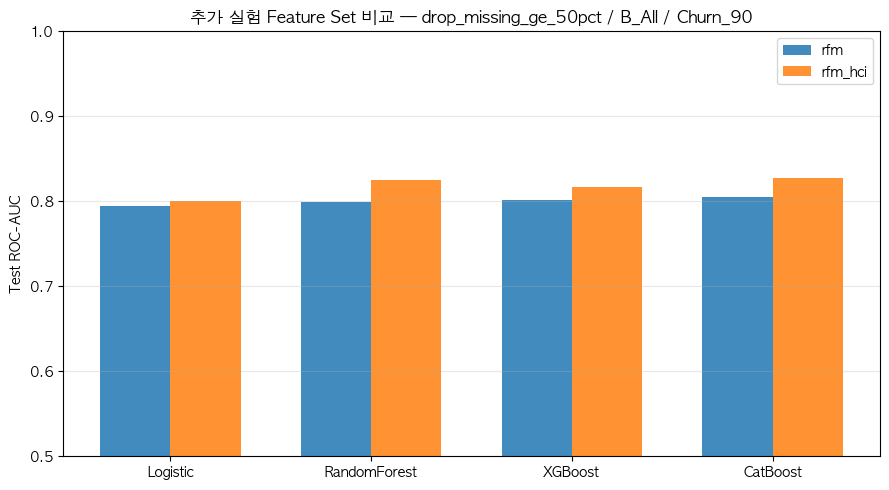

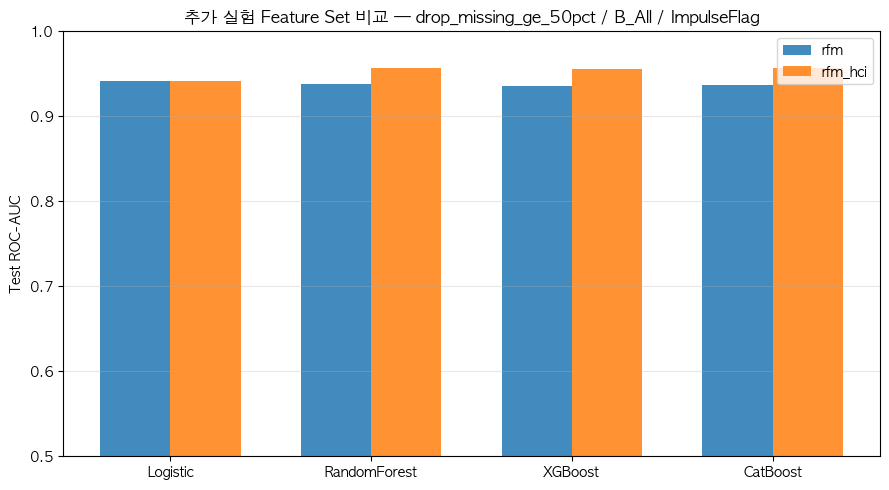

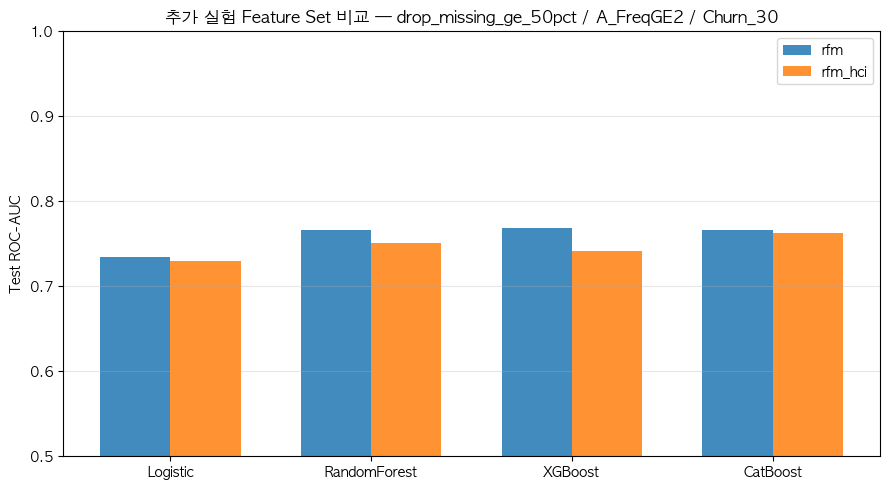

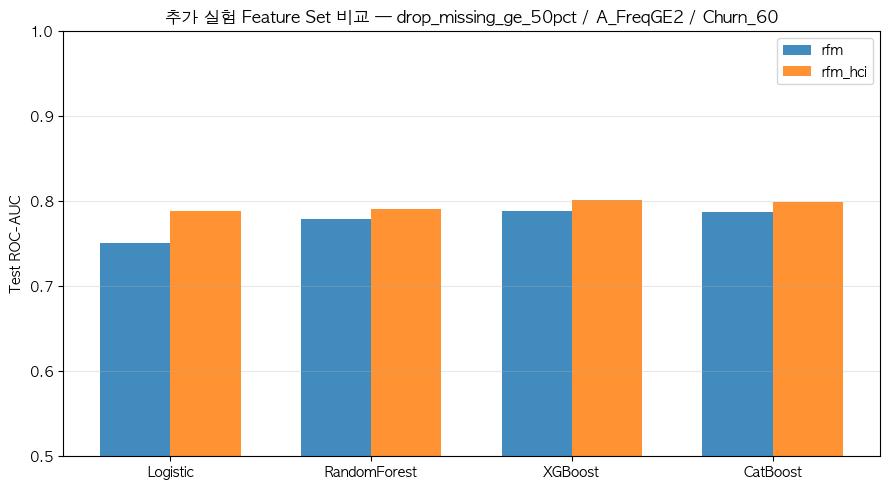

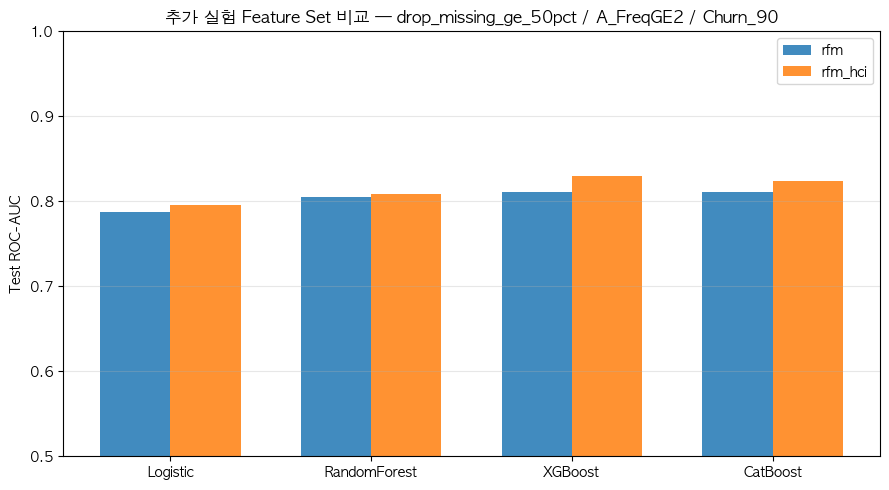

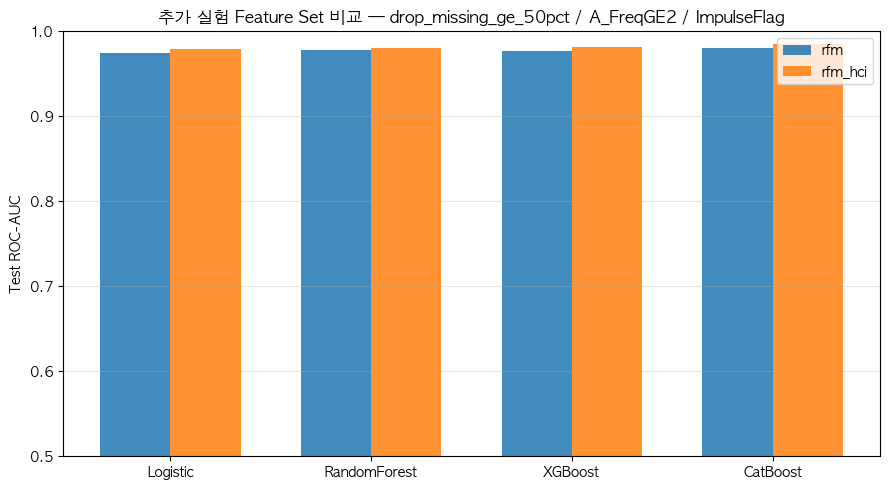

In [50]:
# 추가 실험용 Feature Set 효과 비교 시각화
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 혹시 메모리에 없으면 파일에서 다시 불러오기
if 'variant_results_df' not in globals():
    variant_results_df = pd.read_csv('experiment_results_variants.csv')

def plot_variant_feature_set_comparison(variant_results_df, scenario, dataset_name, target):
    subset = variant_results_df[
        (variant_results_df['Scenario'] == scenario) &
        (variant_results_df['Dataset'] == dataset_name) &
        (variant_results_df['Target'] == target)
    ].copy()

    if subset.empty:
        print(f'데이터 없음: {scenario} / {dataset_name} / {target}')
        return

    fig, ax = plt.subplots(figsize=(9, 5))
    fs_order = ['rfm', 'rfm_hci']
    model_order = get_model_names()
    x = np.arange(len(model_order))
    width = 0.35

    for i, fs in enumerate(fs_order):
        fs_data = subset[subset['FeatureSet'] == fs]
        aucs = [
            fs_data[fs_data['Model'] == m]['Test_AUC'].values[0]
            if len(fs_data[fs_data['Model'] == m]) > 0 else 0
            for m in model_order
        ]
        ax.bar(x + i * width, aucs, width, label=fs, alpha=0.85)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(model_order)
    ax.set_ylabel('Test ROC-AUC')
    ax.set_title(f'추가 실험 Feature Set 비교 — {scenario} / {dataset_name} / {target}')
    ax.legend()
    ax.set_ylim(0.5, 1.0)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'feature_set_comparison_{scenario}_{dataset_name}_{target}.png', dpi=150)
    plt.show()


# 전체 추가 실험 결과 그리기
for scenario in variant_results_df['Scenario'].unique():
    for ds in variant_results_df['Dataset'].unique():
        for target in variant_results_df['Target'].unique():
            plot_variant_feature_set_comparison(variant_results_df, scenario, ds, target)


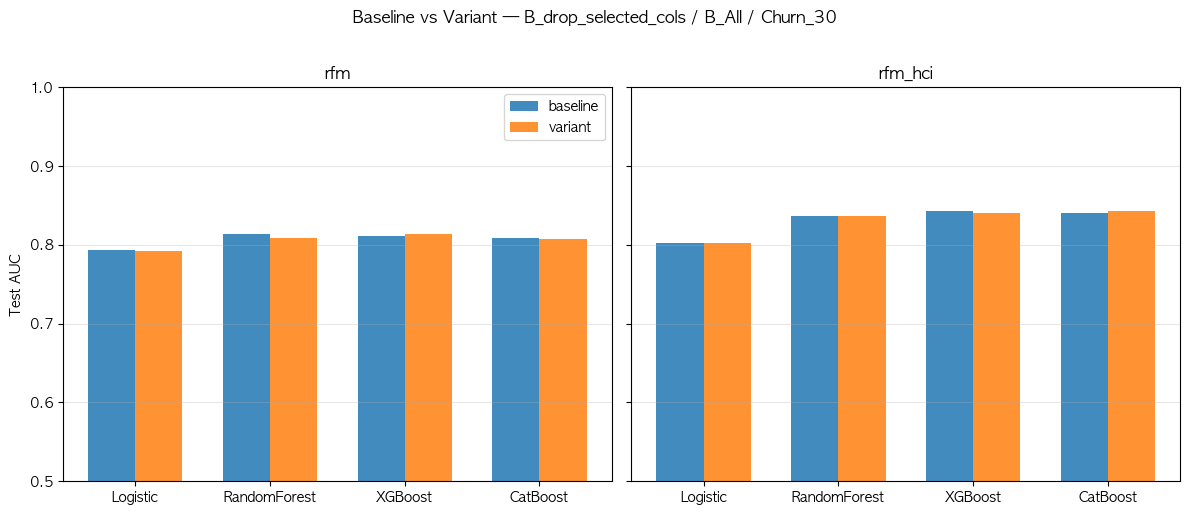

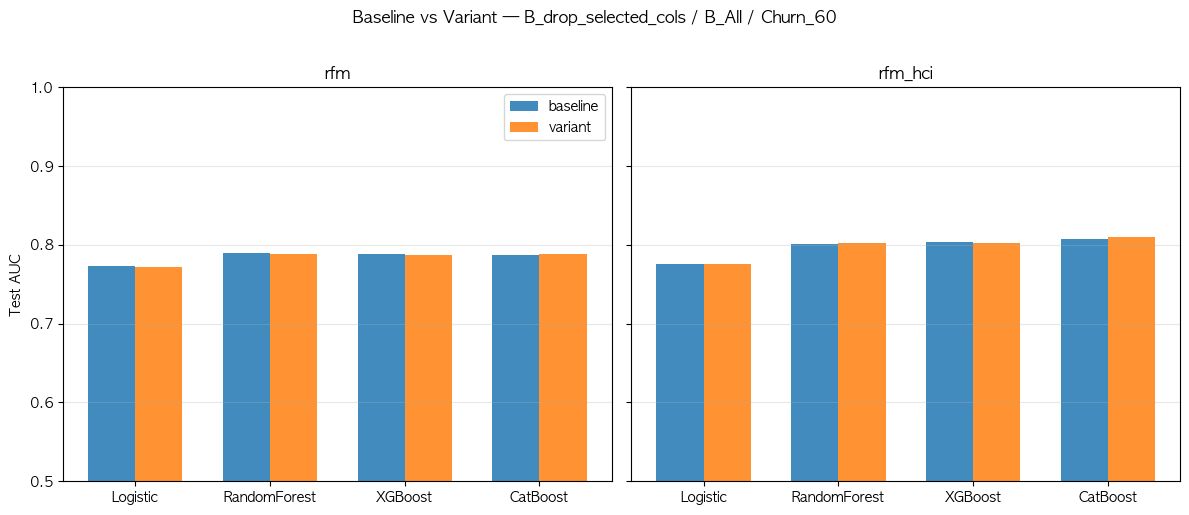

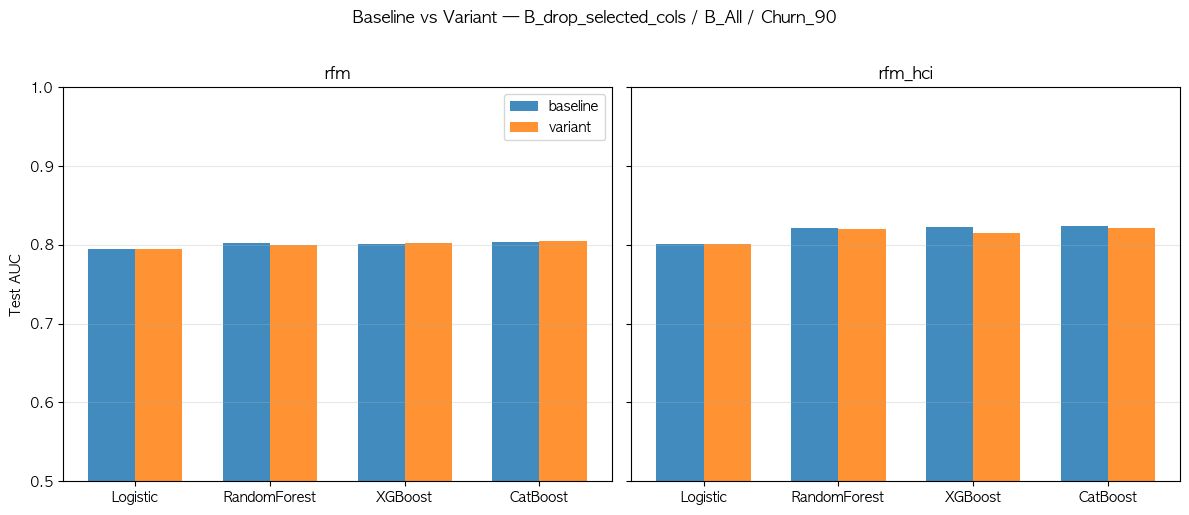

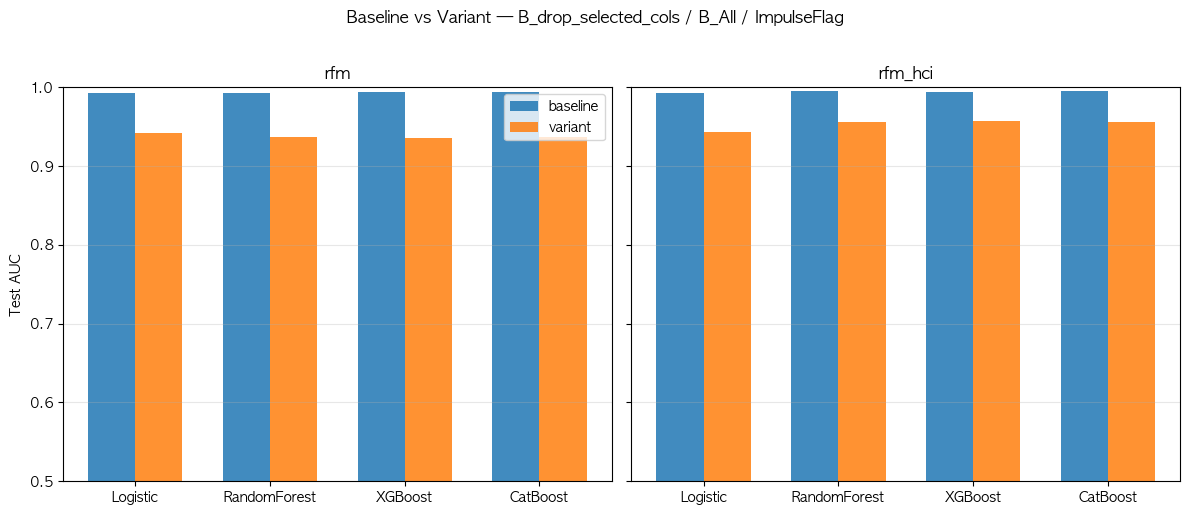

데이터 없음: B_drop_selected_cols / A_FreqGE2 / Churn_30
데이터 없음: B_drop_selected_cols / A_FreqGE2 / Churn_60
데이터 없음: B_drop_selected_cols / A_FreqGE2 / Churn_90
데이터 없음: B_drop_selected_cols / A_FreqGE2 / ImpulseFlag


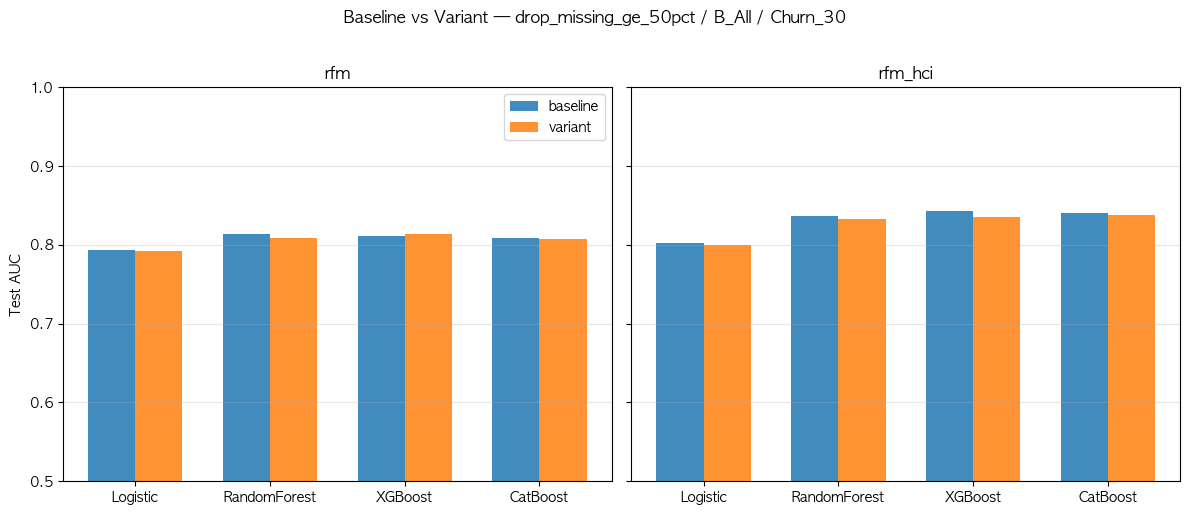

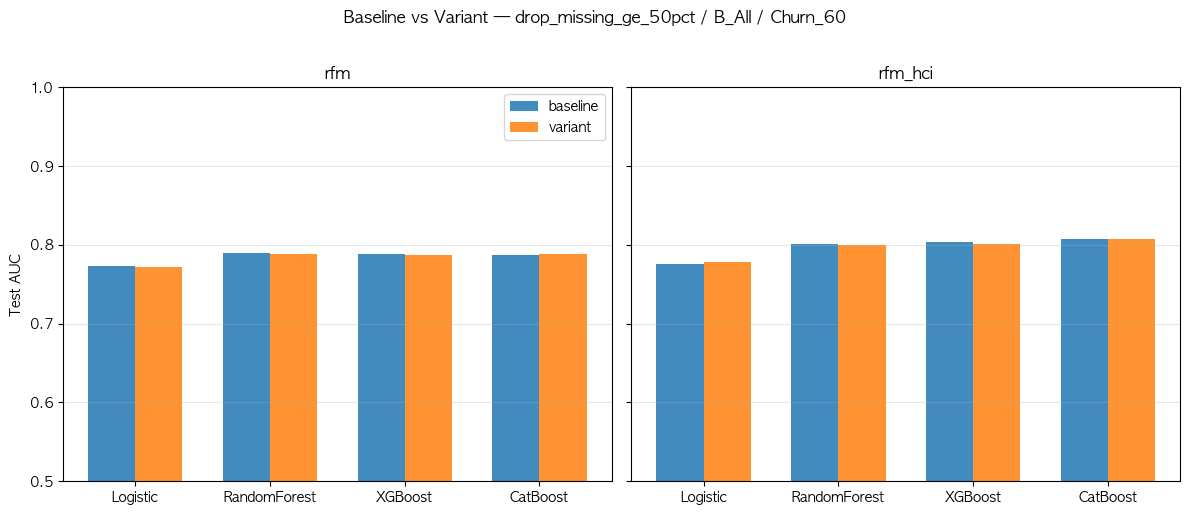

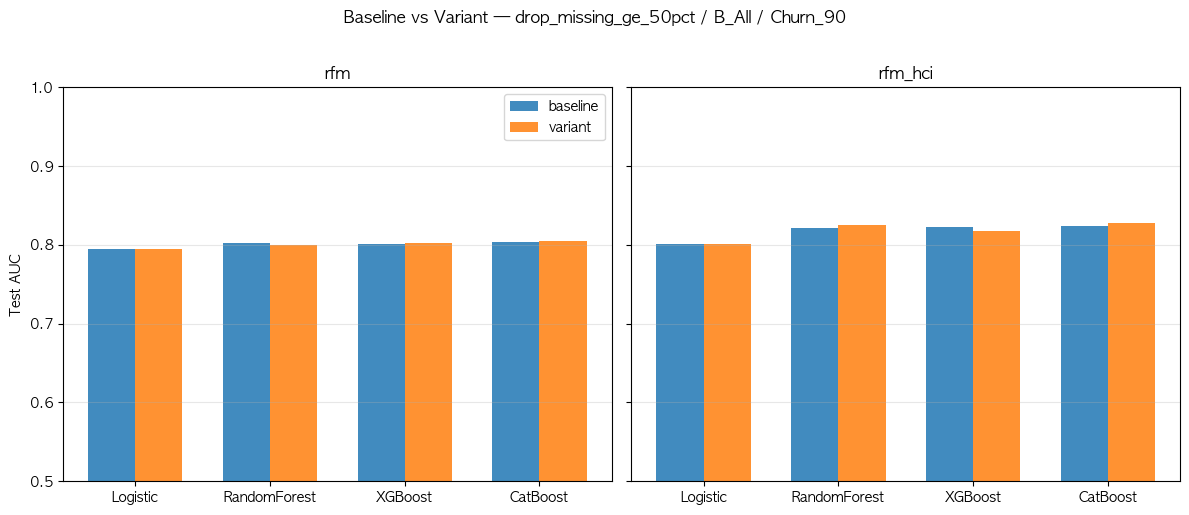

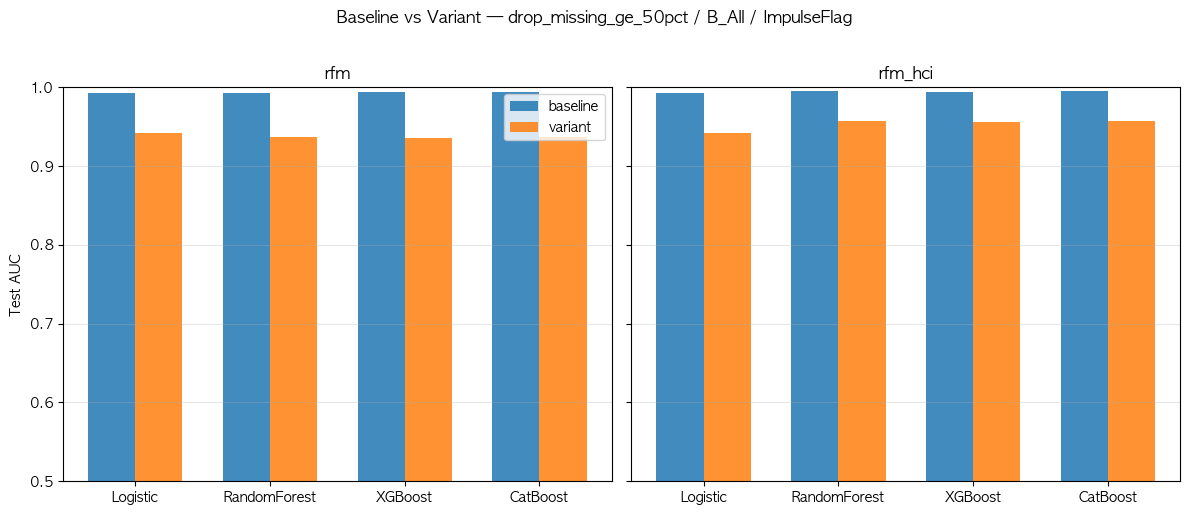

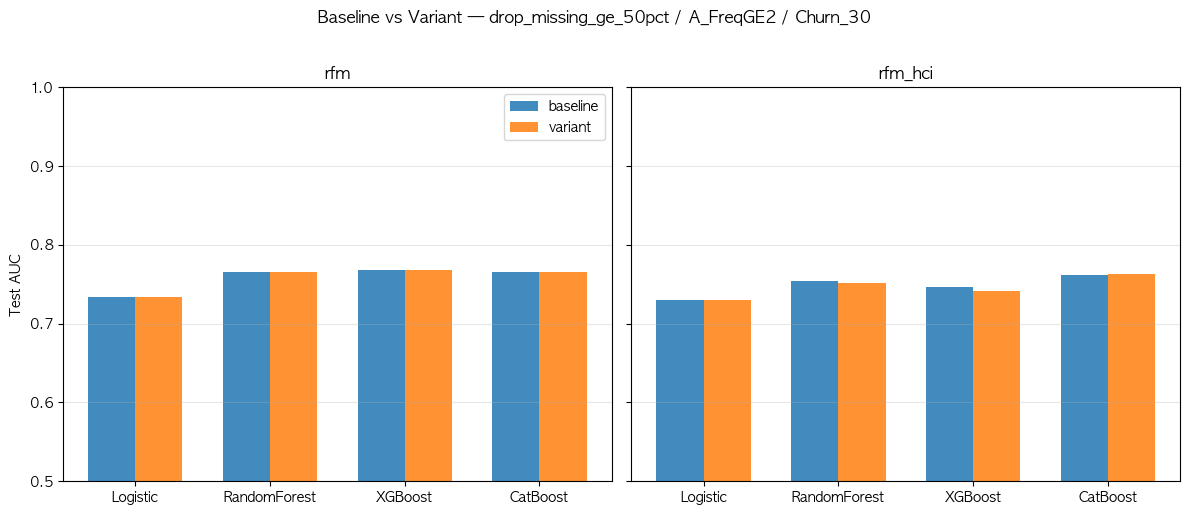

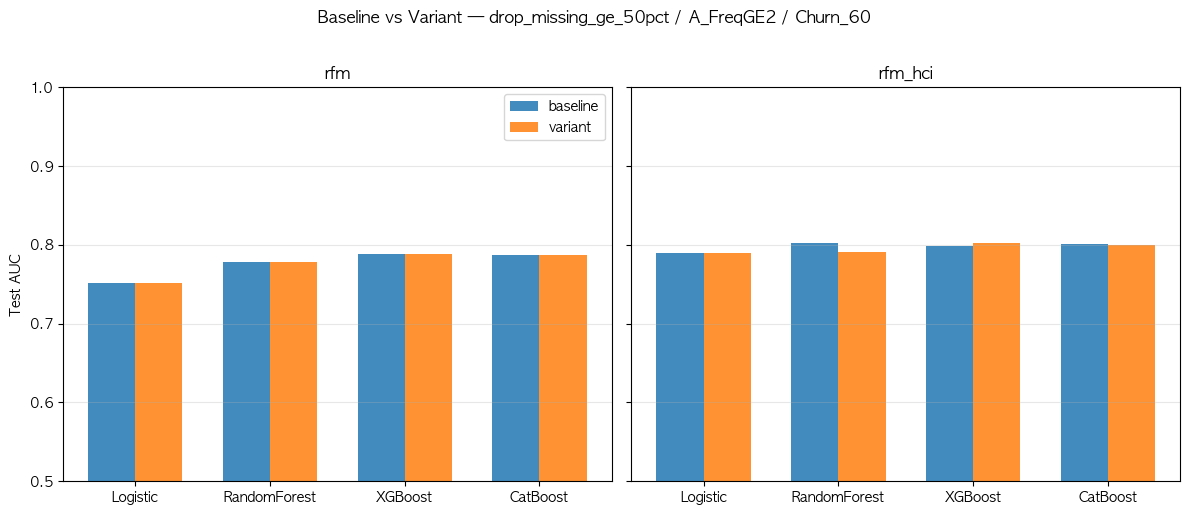

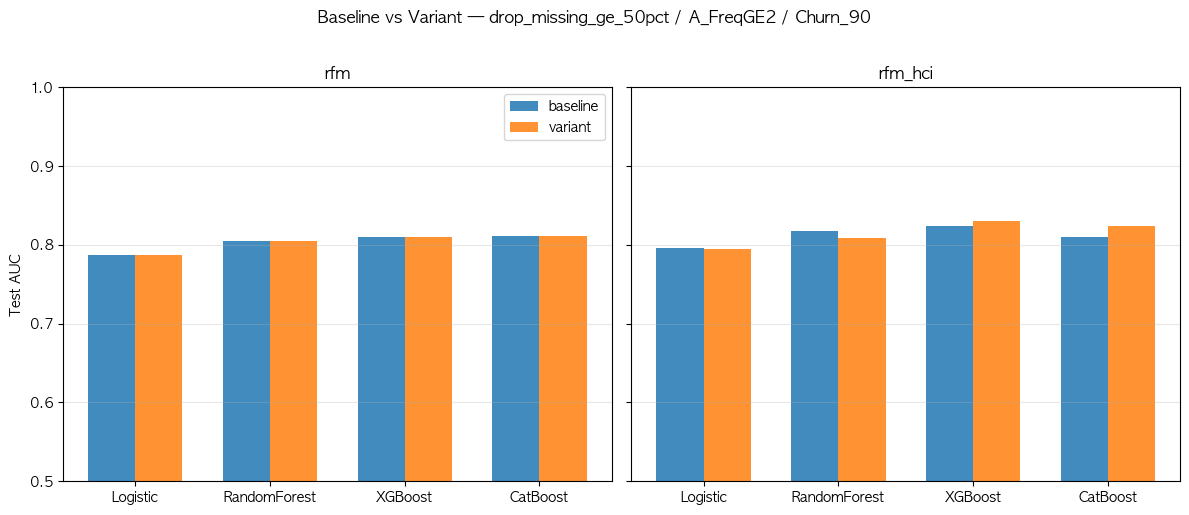

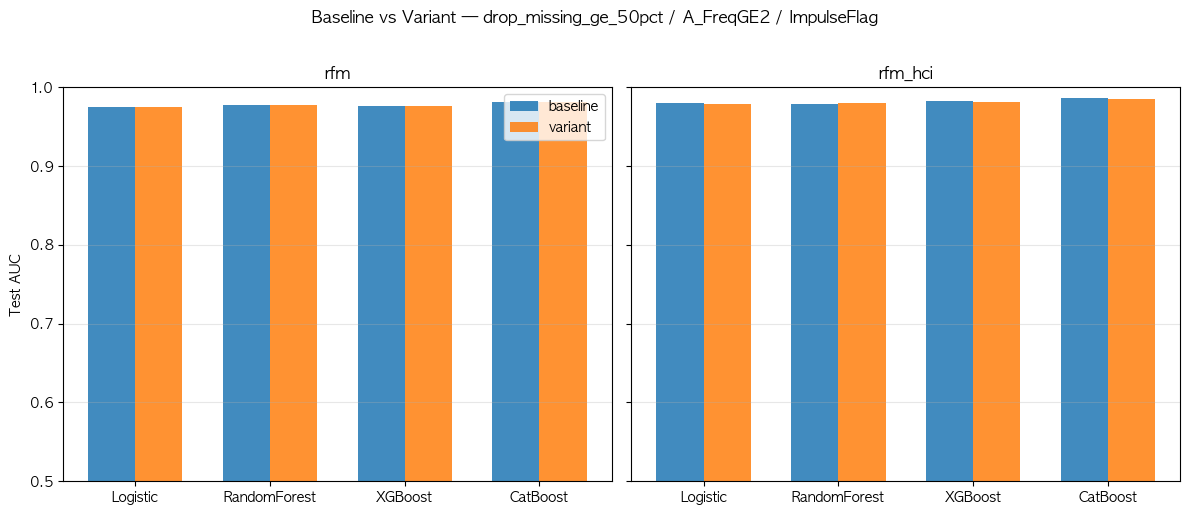

In [52]:
# baseline vs variant 동시 비교 시각화
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

if 'variant_comparison_df' not in globals():
    variant_comparison_df = pd.read_csv('experiment_variant_comparison.csv')

def plot_baseline_vs_variant(variant_comparison_df, scenario, dataset_name, target, metric='AUC'):
    metric = metric.upper()
    base_col = f'Test_{metric}_baseline'
    var_col = f'Test_{metric}_variant'

    subset = variant_comparison_df[
        (variant_comparison_df['Scenario'] == scenario) &
        (variant_comparison_df['Dataset'] == dataset_name) &
        (variant_comparison_df['Target'] == target)
    ].copy()

    if subset.empty:
        print(f'데이터 없음: {scenario} / {dataset_name} / {target}')
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fs_order = ['rfm', 'rfm_hci']
    model_order = get_model_names()
    x = np.arange(len(model_order))
    width = 0.35

    for ax, fs in zip(axes, fs_order):
        fs_data = subset[subset['FeatureSet'] == fs]

        baseline_vals = [
            fs_data[fs_data['Model'] == m][base_col].values[0]
            if len(fs_data[fs_data['Model'] == m]) > 0 else 0
            for m in model_order
        ]
        variant_vals = [
            fs_data[fs_data['Model'] == m][var_col].values[0]
            if len(fs_data[fs_data['Model'] == m]) > 0 else 0
            for m in model_order
        ]

        ax.bar(x - width/2, baseline_vals, width, label='baseline', alpha=0.85)
        ax.bar(x + width/2, variant_vals, width, label='variant', alpha=0.85)

        ax.set_xticks(x)
        ax.set_xticklabels(model_order, rotation=0)
        ax.set_title(fs)
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0.5, 1.0)

    axes[0].set_ylabel(f'Test {metric}')
    axes[0].legend()
    fig.suptitle(f'Baseline vs Variant — {scenario} / {dataset_name} / {target}', y=1.02)

    plt.tight_layout()
    plt.savefig(f'baseline_vs_variant_{metric}_{scenario}_{dataset_name}_{target}.png', dpi=150)
    plt.show()


# 예시: AUC 기준 전체 그림
for scenario in variant_comparison_df['Scenario'].unique():
    for ds in variant_comparison_df['Dataset'].unique():
        for target in variant_comparison_df['Target'].unique():
            plot_baseline_vs_variant(variant_comparison_df, scenario, ds, target, metric='AUC')



[종속변수별 최고 성능표]
  Dataset              Scenario      Target FeatureSet        Model  Test_AUC  Test_F1  Test_Precision  Test_Recall  Test_Accuracy                                                                                                                                           DroppedColumns
A_FreqGE2              baseline    Churn_30        rfm      XGBoost  0.768240 0.726430        0.640327     0.839286       0.688928                                                                                                                                                         
A_FreqGE2              baseline    Churn_60    rfm_hci RandomForest  0.802669 0.604775        0.567164     0.647727       0.738137                                                                                                                                                         
A_FreqGE2              baseline    Churn_90    rfm_hci      XGBoost  0.823682 0.537634        0.396825     0.833333       0.697715  

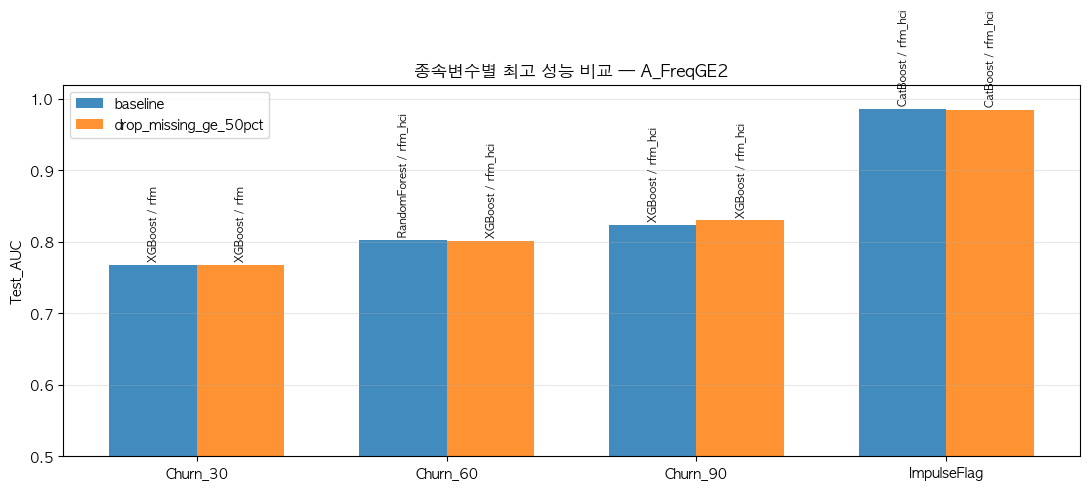

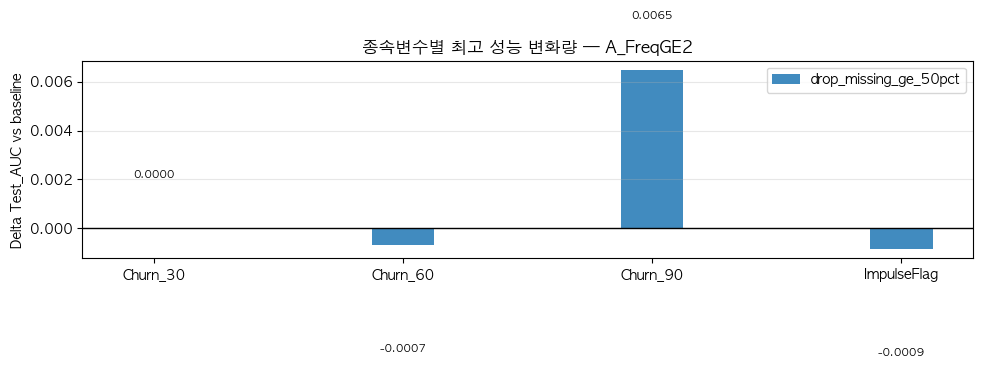

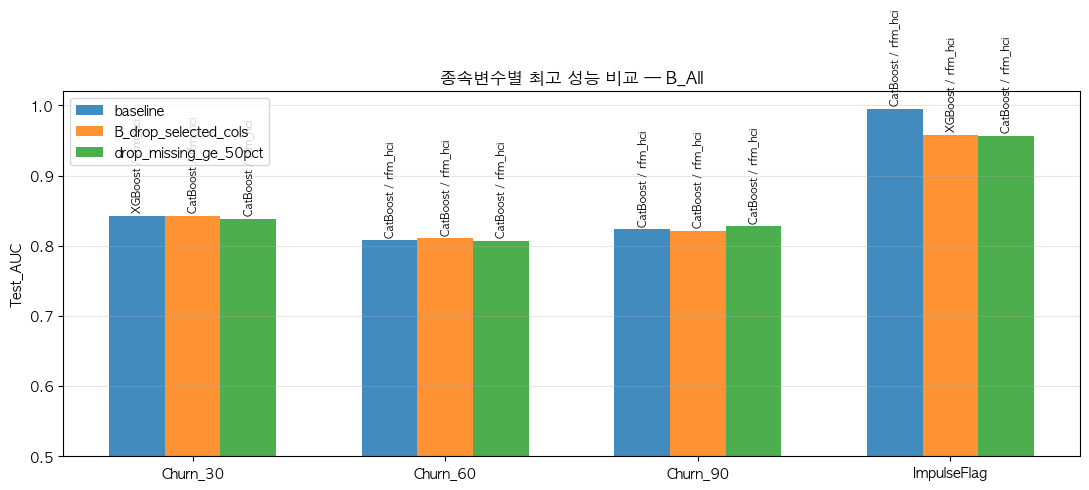

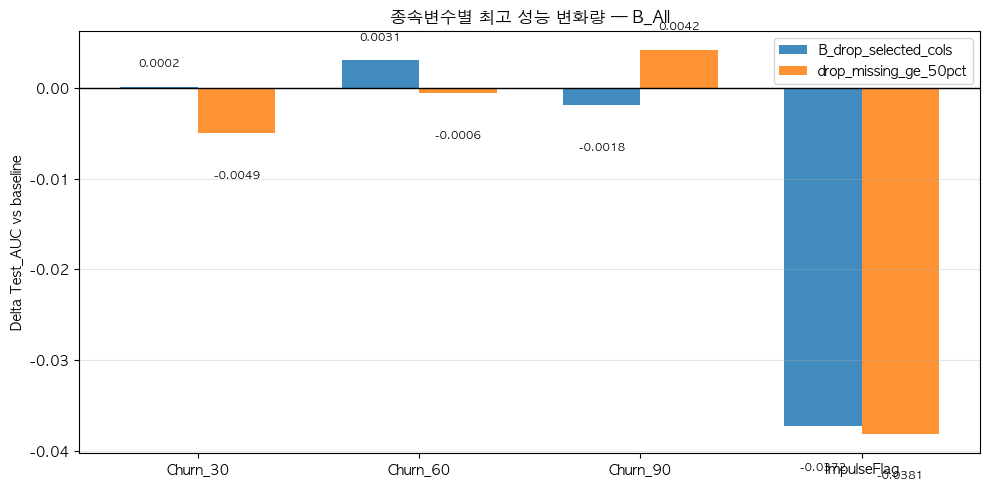

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 결과 불러오기
if 'results_df' not in globals():
    results_df = pd.read_csv('experiment_results.csv')

if 'variant_results_df' not in globals():
    variant_results_df = pd.read_csv('experiment_results_variants.csv')


# 2. baseline + variant 결과 통합
baseline_df = results_df.copy()
baseline_df['Scenario'] = 'baseline'
baseline_df['VariantDescription'] = '원본 모델'
baseline_df['DroppedColumns'] = ''
baseline_df['DroppedColumnCount'] = 0

all_results = pd.concat(
    [baseline_df, variant_results_df],
    ignore_index=True
)


# 3. 각 Dataset / Scenario / Target별 "가장 잘 나온 모델" 추출
def get_best_results_by_target(all_results, metric='Test_AUC'):
    idx = all_results.groupby(['Dataset', 'Scenario', 'Target'])[metric].idxmax()
    best_df = all_results.loc[idx].copy()

    cols = [
        'Dataset', 'Scenario', 'Target',
        'FeatureSet', 'Model',
        metric, 'Test_F1', 'Test_Precision', 'Test_Recall', 'Test_Accuracy',
        'DroppedColumns'
    ]
    cols = [c for c in cols if c in best_df.columns]
    return best_df[cols].sort_values(['Dataset', 'Scenario', 'Target']).reset_index(drop=True)


# 4. baseline 대비 변화량(delta) 계산
def add_delta_from_baseline(best_df, metric='Test_AUC'):
    base = best_df[best_df['Scenario'] == 'baseline'][['Dataset', 'Target', metric]].copy()
    base = base.rename(columns={metric: f'{metric}_baseline'})

    merged = best_df.merge(base, on=['Dataset', 'Target'], how='left')
    merged[f'Delta_{metric}'] = merged[metric] - merged[f'{metric}_baseline']
    return merged


# 5. 절대 성능 그래프
def plot_best_performance_by_target(best_df, dataset_name, metric='Test_AUC'):
    subset = best_df[best_df['Dataset'] == dataset_name].copy()
    if subset.empty:
        print(f'데이터 없음: {dataset_name}')
        return

    target_order = ['Churn_30', 'Churn_60', 'Churn_90', 'ImpulseFlag']
    target_order = [t for t in target_order if t in subset['Target'].unique()]
    scenario_order = ['baseline', 'B_drop_selected_cols', 'drop_missing_ge_50pct']
    scenario_order = [s for s in scenario_order if s in subset['Scenario'].unique()]

    x = np.arange(len(target_order))
    width = 0.22 if len(scenario_order) >= 3 else 0.35

    fig, ax = plt.subplots(figsize=(11, 5))

    for i, scenario in enumerate(scenario_order):
        sc_data = subset[subset['Scenario'] == scenario]
        vals = []
        labels = []
        for t in target_order:
            row = sc_data[sc_data['Target'] == t]
            if len(row) > 0:
                vals.append(row[metric].values[0])
                labels.append(f"{row['Model'].values[0]} / {row['FeatureSet'].values[0]}")
            else:
                vals.append(np.nan)
                labels.append('')

        pos = x + (i - (len(scenario_order) - 1) / 2) * width
        ax.bar(pos, vals, width=width, label=scenario, alpha=0.85)

        for px, py, lab in zip(pos, vals, labels):
            if pd.notna(py):
                ax.text(px, py + 0.005, lab, ha='center', va='bottom', fontsize=8, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(target_order)
    ax.set_ylabel(metric)
    ax.set_title(f'종속변수별 최고 성능 비교 — {dataset_name}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0.5, 1.02 if metric == 'Test_AUC' else 1.0)

    plt.tight_layout()
    plt.show()


# 6. baseline 대비 변화량 그래프
def plot_best_delta_by_target(best_delta_df, dataset_name, metric='Test_AUC'):
    subset = best_delta_df[
        (best_delta_df['Dataset'] == dataset_name) &
        (best_delta_df['Scenario'] != 'baseline')
    ].copy()

    if subset.empty:
        print(f'데이터 없음: {dataset_name}')
        return

    target_order = ['Churn_30', 'Churn_60', 'Churn_90', 'ImpulseFlag']
    target_order = [t for t in target_order if t in subset['Target'].unique()]
    scenario_order = ['B_drop_selected_cols', 'drop_missing_ge_50pct']
    scenario_order = [s for s in scenario_order if s in subset['Scenario'].unique()]

    x = np.arange(len(target_order))
    width = 0.35 if len(scenario_order) == 2 else 0.25

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, scenario in enumerate(scenario_order):
        sc_data = subset[subset['Scenario'] == scenario]
        vals = [
            sc_data[sc_data['Target'] == t][f'Delta_{metric}'].values[0]
            if len(sc_data[sc_data['Target'] == t]) > 0 else np.nan
            for t in target_order
        ]
        pos = x + (i - (len(scenario_order) - 1) / 2) * width
        ax.bar(pos, vals, width=width, label=scenario, alpha=0.85)

        for px, py in zip(pos, vals):
            if pd.notna(py):
                ax.text(px, py + (0.002 if py >= 0 else -0.004), f'{py:.4f}',
                        ha='center', va='bottom' if py >= 0 else 'top', fontsize=8)

    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(target_order)
    ax.set_ylabel(f'Delta {metric} vs baseline')
    ax.set_title(f'종속변수별 최고 성능 변화량 — {dataset_name}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


# 7. 표 + 그래프 실행
metric = 'Test_AUC'   # 'Test_F1' 로 바꿔도 됨

best_df = get_best_results_by_target(all_results, metric=metric)
best_delta_df = add_delta_from_baseline(best_df, metric=metric)

print('\n[종속변수별 최고 성능표]')
print(best_df.to_string(index=False))

print('\n[baseline 대비 변화량 포함 표]')
print(best_delta_df.to_string(index=False))

for ds in sorted(best_df['Dataset'].unique()):
    plot_best_performance_by_target(best_df, ds, metric=metric)
    plot_best_delta_by_target(best_delta_df, ds, metric=metric)
